# Federated Naive Bayes with Institutional Governance Regularization
# EJD-UMA-FedNB-GRC v2.3

| Campo | Detalle |
|---|---|
| Version | v2.3 |
| Fecha | 2026-05-21 |
| Autor | Edgar Oswaldo Herrera Logrono, M.Sc. IA, VIU Espana |
| Programa | EJD-UMA-FedNB-GRC |
| Repeticiones | 10 por configuracion |
| Datasets | NSL-KDD (2009) / CIC-IDS2017 (2017) / UNSW-NB15 (2015) |
| Alphas Dirichlet | 0.05 / 0.10 / 0.20 / 0.30 / 0.50 / 0.70 / 1.00 |
| Split | Train 60% / Val 20% / Test 20% |
| Semilla | 42 |
| Optimizador | Nelder-Mead, 11 puntos de inicio, 800 iteraciones |
| Muestras val optim | 3000 |
| Regularizador | L2, lambda = 0.10 |
| Nodos | Financiero / Salud / Gobierno |

Orden de ejecucion: CELDA1 > CELDA2 > KEEPALIVE > SEC0 > SEC1 > SEC2 > SEC3 >
SEC4 > SEC5 > SEC6 > SEC7 > SEC8DEF > SEC8EXEC > SEC9 > STRESS > RESUMEN > CONCLUSIONES

## CELDA 1 - Google Drive
Ejecutar primero. Esperar a que aparezca "Mounted at /content/drive"
antes de continuar con la siguiente celda.

In [ ]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_DRIVE = Path("/content/drive/MyDrive/EJD_UMA_FedNB_GRC")
    RUTA_DRIVE.mkdir(parents=True, exist_ok=True)
    print(f"[OK] Drive montado: {RUTA_DRIVE}")
except Exception:
    RUTA_DRIVE = Path("resultados_local")
    RUTA_DRIVE.mkdir(parents=True, exist_ok=True)
    print(f"[INFO] Drive no disponible. Usando: {RUTA_DRIVE}")

Mounted at /content/drive
[OK] Drive montado: /content/drive/MyDrive/EJD_UMA_FedNB_GRC


## CELDA 2 - Kaggle
Ejecutar despues de que Drive este montado.
Sube el archivo kaggle.json cuando lo solicite.

In [ ]:
import shutil

ruta_kaggle = Path.home() / ".kaggle"
ruta_kaggle.mkdir(exist_ok=True)
if (ruta_kaggle / "kaggle.json").exists():
    (ruta_kaggle / "kaggle.json").chmod(0o600)
    print("[OK] kaggle.json ya configurado.")
else:
    try:
        from google.colab import files
        archivos = files.upload()
        if "kaggle.json" in archivos:
            shutil.copy("kaggle.json", ruta_kaggle / "kaggle.json")
            (ruta_kaggle / "kaggle.json").chmod(0o600)
            print("[OK] kaggle.json configurado.")
    except Exception:
        print("[!] Coloca kaggle.json en ~/.kaggle/ manualmente.")

Saving kaggle.json to kaggle.json
[OK] kaggle.json configurado.


## KEEPALIVE - Prevenir desconexion de Colab
Ejecutar antes de cualquier corrida larga. Hace click cada 55 segundos.

In [ ]:
try:
    from IPython.display import Javascript, display
    display(Javascript("""
    function keepAlive() {
        var btn = document.querySelector('colab-connect-button');
        if (btn) { btn.shadowRoot.querySelector('paper-icon-button').click(); }
        console.log('keepalive ' + new Date().toLocaleTimeString());
    }
    if (window._kaInterval) clearInterval(window._kaInterval);
    window._kaInterval = setInterval(keepAlive, 55000);
    console.log('Keep-alive activo.');
    """))
    print("[OK] Keep-alive activado. Mantener esta pestana abierta.")
except Exception:
    print("[INFO] Keep-alive no disponible fuera de Colab.")

<IPython.core.display.Javascript object>

[OK] Keep-alive activado. Mantener esta pestana abierta.


## SEC0 - Parametros globales
Todo lo configurable en un solo lugar.
MODO_RAPIDO = True: 1 rep, 500 muestras (prueba ~10 min por dataset)
MODO_RAPIDO = False: 10 reps, 3000 muestras (produccion ~5 horas total)

In [ ]:
VERSION        = "EJD-UMA-FedNB-GRC-v2.3"
SEMILLA        = 42
MODO_RAPIDO    = False

REPETICIONES       = 1     if MODO_RAPIDO else 10
MUESTRAS_VAL_OPTIM = 500   if MODO_RAPIDO else 3000

NIVELES_ALPHA = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

# Regularizador L2. Justificacion: grid search [0.001,0.01,0.05,0.10,0.50]
# sobre NSL-KDD val. Lambda=0.10 maximiza F1-A en 4 de 7 alphas.
LAMBDA_REG = 0.10

# Peso minimo por nodo. Evita colapso a cero bajo alta heterogeneidad.
PISO_W     = 0.05

PROP_VAL           = 0.20
PROP_TEST          = 0.20
TOPE_CIC           = 100_000
MIN_MUESTRAS_CLASE = 5

# Variables CRISC por nodo. Fuente: emails UMA abr-2026.
# ICC = (CMM/5) * KCI * (1 - KRI) * (1 - CVSS/10)
NODOS_CRISC = {
    "Financiero": {"CMM": 4, "KCI": 0.82, "KRI": 0.12, "CVSS": 3.2},
    "Salud":      {"CMM": 3, "KCI": 0.70, "KRI": 0.25, "CVSS": 5.1},
    "Gobierno":   {"CMM": 2, "KCI": 0.55, "KRI": 0.40, "CVSS": 6.8},
}

def calcular_icc(cmm, kci, kri, cvss):
    return round((cmm / 5) * kci * (1 - kri) * (1 - cvss / 10), 3)

for nombre_nodo, v in NODOS_CRISC.items():
    v["ICC"] = calcular_icc(v["CMM"], v["KCI"], v["KRI"], v["CVSS"])

NOMBRES_NODOS = list(NODOS_CRISC.keys())
ICC_POR_NODO  = [NODOS_CRISC[n]["ICC"] for n in NOMBRES_NODOS]
N_NODOS       = len(NOMBRES_NODOS)

COLUMNAS_NSL = [
    "duracion","tipo_protocolo","servicio","bandera",
    "bytes_origen","bytes_destino","tierra","frag_incorrecto",
    "urgente","caliente","intentos_login_fallidos","sesion_iniciada",
    "num_comprometidos","shell_raiz","intento_su","num_raiz",
    "num_creacion_archivos","num_shells","num_archivos_acceso",
    "num_cmds_salida","login_host","login_invitado","conteo",
    "conteo_srv","tasa_serror","tasa_serror_srv","tasa_rerror",
    "tasa_rerror_srv","tasa_mismo_srv","tasa_diff_srv",
    "tasa_diff_host_srv","conteo_host_dst","conteo_srv_host_dst",
    "tasa_mismo_srv_host","tasa_diff_srv_host",
    "tasa_mismo_puerto_src","tasa_diff_host_srv_dst",
    "tasa_serror_host","tasa_serror_srv_host",
    "tasa_rerror_host","tasa_rerror_srv_host","etiqueta",
]
COLS_CAT_NSL  = ["tipo_protocolo", "servicio", "bandera"]
COLS_NUM_NSL  = [c for c in COLUMNAS_NSL if c not in COLS_CAT_NSL + ["etiqueta"]]
COLS_CAT_CIC  = ["Protocol"]
COLS_CAT_UNSW = ["proto", "state", "service"]
EXCLUIR_CIC   = {"Label","Flow ID","Source IP","Source Port",
                 "Destination IP","Destination Port","Timestamp",
                 "External IP","etiqueta"}
EXCLUIR_UNSW  = {"label","attack_cat","id","srcip","sport",
                 "dstip","dsport","Stime","Ltime","etiqueta"}

print(f"Version            : {VERSION}")
print(f"Modo               : {'RAPIDO' if MODO_RAPIDO else 'PRODUCCION'}")
print(f"Repeticiones       : {REPETICIONES}")
print(f"Muestras val optim : {MUESTRAS_VAL_OPTIM}")
print(f"Nodos              : {NOMBRES_NODOS}")
print(f"ICC                : {ICC_POR_NODO}")
print(f"Alphas             : {NIVELES_ALPHA}")
print("[OK] SEC0 - parametros cargados.")

Version            : EJD-UMA-FedNB-GRC-v2.3
Modo               : PRODUCCION
Repeticiones       : 10
Muestras val optim : 3000
Nodos              : ['Financiero', 'Salud', 'Gobierno']
ICC                : [0.393, 0.154, 0.042]
Alphas             : [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
[OK] SEC0 - parametros cargados.


## SEC1 - Entorno e importaciones

In [ ]:
import gc, time, warnings, logging, subprocess
from datetime import datetime
import numpy as np
import pandas as pd
import requests
from scipy.optimize    import minimize
from scipy.stats       import chi2, wilcoxon as scipy_wilcoxon
from scipy.special     import logsumexp
from scipy.spatial.distance import jensenshannon
from sklearn.naive_bayes    import CategoricalNB, GaussianNB
from sklearn.preprocessing  import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import f1_score
import matplotlib.pyplot as plt
from IPython.display import Audio, display
warnings.filterwarnings("ignore")
np.random.seed(SEMILLA)

marca_sesion = datetime.now().strftime("%Y%m%d_%H%M%S")
RUTAS = {
    "nsl":      Path("datos/nsl_kdd"),
    "cic":      Path("datos/cicids2017"),
    "unsw":     Path("datos/unsw_nb15"),
    "figuras":  RUTA_DRIVE / "figuras",
    "metricas": RUTA_DRIVE / "metricas",
    "logs":     RUTA_DRIVE / "logs",
}
for r in RUTAS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"[OK] Resultados se guardan en: {RUTA_DRIVE}")

logging.basicConfig(
    filename=str(RUTAS["logs"] / f"sesion_{marca_sesion}.log"),
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt="%H:%M:%S",
)
bitacora = logging.getLogger("EJD_UMA")
bitacora.info(f"Inicio {VERSION} sesion={marca_sesion}")

def alerta_exito():
    try:
        tasa = 22050
        sil  = np.zeros(int(tasa * 0.08))
        t    = np.linspace(0, 0.20, int(tasa * 0.20), endpoint=False)
        b    = 0.4 * np.sin(2 * np.pi * 432 * t) * np.exp(-6 * t)
        display(Audio(np.concatenate([b, sil, b]), rate=tasa, autoplay=True))
    except Exception:
        pass

def alerta_error():
    try:
        tasa = 22050
        sil  = np.zeros(int(tasa * 0.07))
        def tono(f):
            t = np.linspace(0, 0.18, int(tasa * 0.18), endpoint=False)
            return 0.4 * np.sin(2 * np.pi * f * t) * np.exp(-4 * t)
        display(Audio(np.concatenate([tono(440), sil, tono(330), sil, tono(220)]),
                      rate=tasa, autoplay=True))
    except Exception:
        pass

print(f"Sesion : {marca_sesion}")
print("[OK] SEC1 - entorno listo.")

[OK] Resultados se guardan en: /content/drive/MyDrive/EJD_UMA_FedNB_GRC
Sesion : 20260522_010428
[OK] SEC1 - entorno listo.


## SEC2 - Carga y limpieza de datos

In [ ]:
def kaggle_descargar(id_dataset, carpeta):
    if any(carpeta.glob("*.*")):
        return True
    try:
        subprocess.run(["pip","install","kaggle","-q"],
                       check=True, capture_output=True)
        res = subprocess.run(
            ["kaggle","datasets","download","-d",
             id_dataset,"--unzip","-p",str(carpeta)],
            capture_output=True, text=True, timeout=600)
        if res.returncode == 0:
            print(f"  [OK] Kaggle: {id_dataset}")
            return True
        print(f"  [!] Kaggle error: {res.stderr[:200]}")
        return False
    except Exception as e:
        print(f"  [!] Kaggle fallo: {e}")
        return False

def descargar_url(url, ruta, timeout=90):
    if ruta.exists() and ruta.stat().st_size > 5000:
        return True
    try:
        r = requests.get(url, timeout=timeout, stream=True)
        r.raise_for_status()
        ruta.write_bytes(r.content)
        return True
    except Exception:
        return False

def cargar_nsl_kdd():
    arch_tr = RUTAS["nsl"] / "KDDTrain+.txt"
    arch_te = RUTAS["nsl"] / "KDDTest+.txt"
    for url in [
        "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt",
        "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt",
    ]:
        if descargar_url(url, arch_tr): break
    for url in [
        "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt",
        "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt",
    ]:
        if descargar_url(url, arch_te): break
    partes = []
    for arch in [arch_tr, arch_te]:
        if not arch.exists():
            raise FileNotFoundError(f"NSL-KDD no encontrado: {arch}")
        df = pd.read_csv(arch, header=None,
                         names=COLUMNAS_NSL + ["dificultad"])
        df = df.drop(columns=["dificultad"], errors="ignore")
        df["etiqueta"] = df["etiqueta"].str.strip().str.rstrip(".")
        partes.append(df)
    return partes[0], partes[1]

def cargar_cicids2017():
    kaggle_descargar("dhoogla/cicids2017", RUTAS["cic"])
    parquets = sorted(RUTAS["cic"].glob("*.parquet"))
    if parquets:
        dfs = []
        for pq in parquets:
            df_pq = pd.read_parquet(pq)
            col_label = next(
                (c for c in df_pq.columns if c.strip().lower() == "label"), None)
            if col_label is None:
                df_pq["Label"] = "BENIGN" if "benign" in pq.stem.lower() else pq.stem
            elif col_label != "Label":
                df_pq = df_pq.rename(columns={col_label: "Label"})
            dfs.append(df_pq)
        df = pd.concat(dfs, ignore_index=True)
        print(f"  CIC-IDS2017: {len(df):,} registros (Parquet)")
        return df
    csvs = sorted(RUTAS["cic"].glob("*.csv"))
    if csvs:
        df = pd.concat([pd.read_csv(f, low_memory=False) for f in csvs], ignore_index=True)
        print(f"  CIC-IDS2017: {len(df):,} registros (CSV)")
        return df
    raise FileNotFoundError("[!] CIC-IDS2017 no encontrado. Kaggle: dhoogla/cicids2017")

def cargar_unsw_nb15():
    kaggle_descargar("mrwellsdavid/unsw-nb15", RUTAS["unsw"])
    candidatos = ["UNSW_NB15_training-set.csv","UNSW-NB15_training-set.csv","UNSW_NB15.csv"]
    arch_tr = next((RUTAS["unsw"]/n for n in candidatos
                    if (RUTAS["unsw"]/n).exists()), None)
    if arch_tr is None:
        csvs = sorted([f for f in RUTAS["unsw"].glob("*.csv")
                       if "feature" not in f.name.lower()
                       and f.stat().st_size > 1_000_000],
                      key=lambda f: f.stat().st_size, reverse=True)
        if not csvs:
            raise FileNotFoundError("[!] UNSW-NB15. Kaggle: mrwellsdavid/unsw-nb15")
        arch_tr = csvs[0]
    df_tr = pd.read_csv(arch_tr, low_memory=False)
    cand_te = ["UNSW_NB15_testing-set.csv","UNSW-NB15_testing-set.csv"]
    arch_te = next((RUTAS["unsw"]/n for n in cand_te
                    if (RUTAS["unsw"]/n).exists()), None)
    df_te = pd.read_csv(arch_te, low_memory=False) if arch_te else None
    print(f"  UNSW-NB15: {len(df_tr):,} train" +
          (f" + {len(df_te):,} test" if df_te is not None else ""))
    return df_tr, df_te

def binarizar_etiqueta(serie):
    s = serie.astype(str).str.strip().str.lower()
    return (~s.isin(["normal","benign","0"])).astype(int)

def preparar_y_limpiar(datos_brutos, columna_etiqueta,
                        cols_cat, excluir_set, nombre_ds, modo="binario"):
    print(f"\n  --- Limpieza: {nombre_ds} ---")
    df = datos_brutos.copy()
    df.columns = df.columns.str.strip()
    columna_etiqueta = columna_etiqueta.strip()
    n_inicial = len(df)
    print(f"  Registros iniciales: {n_inicial:,}")
    if columna_etiqueta not in df.columns:
        raise ValueError(f"Columna '{columna_etiqueta}' no encontrada. "
                         f"Disponibles: {list(df.columns[:6])}")
    for col in ["service","proto","state"]:
        if col in df.columns:
            df[col] = df[col].fillna("-").astype(str)
    if modo == "binario":
        df["etiqueta"] = binarizar_etiqueta(df[columna_etiqueta])
    else:
        df["etiqueta"] = df[columna_etiqueta].astype(str).str.strip()
        df = df[~df["etiqueta"].isin(["","nan","NaN"])]
    if columna_etiqueta != "etiqueta":
        df = df.drop(columns=[columna_etiqueta], errors="ignore")
    df = df[df["etiqueta"].notna()]
    cols_cat_ok = [c for c in cols_cat if c in df.columns]
    cols_num_ok = [
        c for c in df.columns
        if c not in excluir_set and c not in cols_cat_ok
        and c != "etiqueta" and pd.api.types.is_numeric_dtype(df[c])
    ]
    for col in ["Flow Bytes/s","Flow Packets/s"]:
        if col in df.columns:
            df[col] = df[col].replace([np.inf,-np.inf], np.nan)
    df[cols_num_ok] = df[cols_num_ok].replace([np.inf,-np.inf], np.nan)
    n0 = len(df); df = df.drop_duplicates()
    if len(df) < n0:
        print(f"  Duplicados eliminados: {n0-len(df):,}")
    n0 = len(df); df = df.dropna(subset=cols_cat_ok + cols_num_ok + ["etiqueta"])
    if len(df) < n0:
        print(f"  NaN/Inf eliminados: {n0-len(df):,}")
    conteo = df["etiqueta"].value_counts()
    clases_ok = conteo[conteo >= MIN_MUESTRAS_CLASE].index
    n0 = len(df); df = df[df["etiqueta"].isin(clases_ok)].reset_index(drop=True)
    if len(df) < n0:
        print(f"  Clases escasas eliminadas: {n0-len(df):,}")
    n_final = len(df)
    print(f"  Registros finales: {n_final:,} ({100*n_final/n_inicial:.1f}%)")
    print(f"  Clases: {dict(df['etiqueta'].value_counts().sort_index())}")
    return df, cols_cat_ok, cols_num_ok

def submuestreo_estratificado(df, tope, semilla):
    if len(df) <= tope:
        return df
    clase_mayor = df["etiqueta"].value_counts().idxmax()
    df_min = df[df["etiqueta"] != clase_mayor]
    df_may = df[df["etiqueta"] == clase_mayor]
    cupo_may = tope - len(df_min)
    if cupo_may < MIN_MUESTRAS_CLASE:
        prop = len(df_may)/len(df)
        n_may = max(MIN_MUESTRAS_CLASE, int(tope*prop))
        n_min = max(MIN_MUESTRAS_CLASE, tope-n_may)
        df_may_s = df_may.sample(n=min(n_may,len(df_may)), random_state=semilla)
        df_min_s = df_min.sample(n=min(n_min,len(df_min)), random_state=semilla)
    else:
        df_may_s = df_may.sample(n=min(cupo_may,len(df_may)), random_state=semilla)
        df_min_s = df_min
    resultado = (pd.concat([df_may_s,df_min_s])
                 .sample(frac=1,random_state=semilla)
                 .reset_index(drop=True))
    print(f"  Submuestreo: {len(df):,} -> {len(resultado):,}")
    return resultado

print("[OK] SEC2 - carga y limpieza definidos.")

[OK] SEC2 - carga y limpieza definidos.


## SEC3 - Auditoria de datos

In [ ]:
def auditar_dataset(datos_limpios, cols_cat, cols_num, nombre):
    sep = "=" * 55
    print(sep)
    print(f"  AUDITORIA: {nombre}")
    print(sep)
    for cls, n in datos_limpios["etiqueta"].value_counts().sort_index().items():
        print(f"  Clase {str(cls):<20}: {n:,} ({100*n/len(datos_limpios):.1f}%)")
    nan_c = datos_limpios[cols_cat].isna().sum().sum()
    nan_n = datos_limpios[cols_num].isna().sum().sum()
    inf_n = np.isinf(datos_limpios[cols_num].values.astype(float)).sum()
    print(f"  NaN cat={nan_c} num={nan_n} | Inf={inf_n}")
    if nan_c + nan_n + inf_n > 0:
        print("  [!] ALERTA: valores problematicos presentes")
    print(sep)

print("[OK] SEC3 - auditoria definida.")

[OK] SEC3 - auditoria definida.


## SEC4 - Verificacion de parametros

In [ ]:
sep = "=" * 55
print(sep); print("  PROTOCOLO-VERIFICACION"); print(sep)
problemas = []

ref_icc = {"Financiero":0.393,"Salud":0.154,"Gobierno":0.042}
for nombre_n, icc_esp in ref_icc.items():
    v = NODOS_CRISC[nombre_n]
    icc_cal = calcular_icc(v["CMM"],v["KCI"],v["KRI"],v["CVSS"])
    ok = abs(icc_cal-icc_esp) < 0.001
    print(f"  [{'OK' if ok else 'FALLO'}] ICC {nombre_n}: {icc_cal} (ref={icc_esp})")
    if not ok: problemas.append(f"ICC {nombre_n}")

ok_a = len(NIVELES_ALPHA)==7 and NIVELES_ALPHA==sorted(NIVELES_ALPHA)
print(f"  [{'OK' if ok_a else 'FALLO'}] 7 alphas: {NIVELES_ALPHA}")
if not ok_a: problemas.append("Alphas")

np.random.seed(SEMILLA); a1=np.random.rand(5)
np.random.seed(SEMILLA); a2=np.random.rand(5)
ok_s = np.allclose(a1,a2)
print(f"  [{'OK' if ok_s else 'FALLO'}] Semilla {SEMILLA} reproducible")
if not ok_s: problemas.append("Semilla")

print(f"  [OK] REPETICIONES={REPETICIONES} | MUESTRAS_VAL_OPTIM={MUESTRAS_VAL_OPTIM}")
print(f"  [OK] Wilcoxon viable: {REPETICIONES >= 6}")

print(sep)
if problemas:
    alerta_error()
    raise RuntimeError(f"Protocolo-Verificacion: {problemas}. Corregir en SEC0.")
print("  VERIFICACION APROBADA")
print(sep)
print("[OK] SEC4.")

  PROTOCOLO-VERIFICACION
  [OK] ICC Financiero: 0.393 (ref=0.393)
  [OK] ICC Salud: 0.154 (ref=0.154)
  [OK] ICC Gobierno: 0.042 (ref=0.042)
  [OK] 7 alphas: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
  [OK] Semilla 42 reproducible
  [OK] REPETICIONES=10 | MUESTRAS_VAL_OPTIM=3000
  [OK] Wilcoxon viable: True
  VERIFICACION APROBADA
[OK] SEC4.


## SEC5 - Preprocesado hibrido
OrdinalEncoder ajustado exclusivamente sobre entrenamiento.
Valores OOD en inferencia van al slot n_cats[j], uno mas alla del
ultimo codigo conocido. El encoder se ajusta solo sobre entrenamiento. Valores OOD van al slot n_cats[j].

In [ ]:
class PreprocesadorHibrido:
    def __init__(self, cols_cat, cols_num):
        self.cols_cat    = cols_cat
        self.cols_num    = cols_num
        self.codificador = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1, dtype=np.float64)
        self.escalador   = StandardScaler()
        self.n_cats_tr   = None
        self.clases      = None

    def ajustar_transformar(self, df_tr):
        mat_cat = df_tr[self.cols_cat].astype(str).values
        mat_num = df_tr[self.cols_num].values.astype(np.float64)
        etiq    = df_tr["etiqueta"].values
        mat_cat_cod = self.codificador.fit_transform(mat_cat).astype(int)
        mat_num_esc = self.escalador.fit_transform(mat_num)
        self.n_cats_tr = [len(c) for c in self.codificador.categories_]
        self.clases    = np.unique(etiq)
        return mat_cat_cod, mat_num_esc, etiq

    def transformar(self, df):
        mat_cat = df[self.cols_cat].astype(str).values
        mat_num = df[self.cols_num].values.astype(np.float64)
        etiq    = df["etiqueta"].values
        mat_cat_cod = self.codificador.transform(mat_cat)
        for j, n in enumerate(self.n_cats_tr):
            mat_cat_cod[mat_cat_cod[:,j] < 0, j] = n
        mat_num_esc = self.escalador.transform(mat_num)
        return mat_cat_cod.astype(int), mat_num_esc, etiq


class NaiveBayesHibrido:
    """
    Clasificador hibrido: CategoricalNB para rasgos nominales,
    GaussianNB para rasgos numericos.

    La verosimilitud combinada por clase es:
        log P(x|c,k) = log P_CAT(x_qual|c,k)
                     + log P_GAUSS(x_num|c,k)
                     - log P(c)
    El prior se resta una vez para evitar doble conteo,
    ya que ambos modelos de sklearn lo incluyen en predict_log_proba.

    El servidor combina K modelos locales como Mezcla de Gaussianas (MoG):
        log P_MoG(x|c) = logsumexp_k [ log(w_k) + log P(x|c,k) ]
    Los pesos w_k son aprendidos por Nelder-Mead con prior ICC.
    """

    def __init__(self, suavizado=1.0):
        self.suavizado = suavizado
        self.nb_cat    = None
        self.nb_gauss  = None
        self.n_cats    = None
        self.clases    = None

    def entrenar(self, cat, num, etiq):
        self.n_cats = [int(cat[:,j].max())+1 for j in range(cat.shape[1])]
        self.nb_cat = CategoricalNB(
            alpha=self.suavizado,
            min_categories=[n+1 for n in self.n_cats])
        self.nb_cat.fit(cat, etiq)
        self.nb_gauss = GaussianNB()
        self.nb_gauss.fit(num, etiq)
        self.clases = self.nb_cat.classes_
        return self

    def _mapear_ood(self, cat):
        mat = cat.astype(float).copy()
        for j, n in enumerate(self.n_cats):
            col = mat[:,j]
            col = np.maximum(col, 0)
            col = np.where(col >= n, n, col)
            mat[:,j] = col
        return mat.astype(int)

    def log_verosimilitud(self, cat, num):
        lp_cat   = self.nb_cat.predict_log_proba(self._mapear_ood(cat))
        lp_num   = self.nb_gauss.predict_log_proba(num)
        lp_prior = self.nb_cat.class_log_prior_
        return lp_cat + lp_num - lp_prior

    def predecir(self, cat, num):
        return self.clases[np.argmax(self.log_verosimilitud(cat,num),axis=1)]

    def predecir_proba(self, cat, num):
        lp = self.log_verosimilitud(cat, num)
        lp -= lp.max(axis=1, keepdims=True)
        p   = np.exp(lp)
        return p / p.sum(axis=1, keepdims=True)


def dividir_estratificado(df, semilla):
    df_tr, df_tmp = train_test_split(
        df, test_size=PROP_VAL+PROP_TEST,
        stratify=df["etiqueta"], random_state=semilla)
    df_val, df_te = train_test_split(
        df_tmp, test_size=PROP_TEST/(PROP_VAL+PROP_TEST),
        stratify=df_tmp["etiqueta"], random_state=semilla)
    return df_tr, df_val, df_te

print("[OK] SEC5 - preprocesado definido.")

[OK] SEC5 - preprocesado definido.


## SEC6 - Modelo federado y servidor MoG

Implementa la Mezcla de Gaussianas real descrita en el preprint.
El servidor no colapsa las distribuciones locales en un vector global.
Cada nodo mantiene su identidad estadistica.

Parametros Nelder-Mead:
  - 11 puntos de inicio sistematicos (vertices, aristas, Dirichlet)
  - 800 iteraciones maximas por punto
  - MUESTRAS_VAL_OPTIM muestras de validacion para la funcion objetivo

Regularizador L2:
  J(w) = ANLL_norm(w) + lambda * ||w - ICC_norm||^2
  ANLL_norm: log-softmax antes del calculo evita escala en millones.
  ICC_norm: ICC proyectado al simplex de probabilidad.

In [ ]:
def repartir_dirichlet(df_entreno, num_nodos, alpha, semilla):
    gen    = np.random.default_rng(semilla)
    clases = sorted(df_entreno["etiqueta"].unique())
    partes = [[] for _ in range(num_nodos)]
    for c in clases:
        idx_c = df_entreno[df_entreno["etiqueta"]==c].index.tolist()
        gen.shuffle(idx_c)
        props  = gen.dirichlet([alpha]*num_nodos)
        cortes = (np.cumsum(props)*len(idx_c)).astype(int)
        inicio = 0
        for k, fin in enumerate(cortes):
            partes[k].extend(idx_c[inicio:fin])
            inicio = fin
    return [df_entreno.loc[p].reset_index(drop=True)
            for p in partes if len(p) > 1]

def js_entre_nodos(particiones):
    clases = sorted(set().union(*[set(p["etiqueta"].unique()) for p in particiones]))
    distribs = []
    for parte in particiones:
        frec = parte["etiqueta"].value_counts(normalize=True)
        distribs.append([frec.get(c,0) for c in clases])
    pares = [(i,j) for i in range(len(distribs)) for j in range(i+1,len(distribs))]
    return np.mean([jensenshannon(distribs[i],distribs[j]) for i,j in pares])

def entrenar_modelos_locales(particiones, preprocesador):
    modelos, tamanos = [], []
    for parte in particiones:
        cat, num, etiq = preprocesador.transformar(parte)
        if len(np.unique(etiq)) < 2:
            continue
        m = NaiveBayesHibrido()
        m.entrenar(cat, num, etiq)
        modelos.append(m)
        tamanos.append(len(etiq))
    return modelos, np.array(tamanos)

def indices_activos_mog(modelos):
    if not modelos:
        return []
    n_ref = len(modelos[0].clases)
    return [i for i, m in enumerate(modelos) if len(m.clases) == n_ref]

def log_prob_servidor_mog(modelos, pesos, cat, num, verbose=True):
    """
    Mezcla de Gaussianas real en el servidor.
    Para cada muestra x y clase c:
        log P_MoG(x|c) = logsumexp_k [ log(w_k) + log P_k(x|c) ]

    """
    idx = indices_activos_mog(modelos)
    if not idx:
        return modelos[0].log_verosimilitud(cat, num)
    if verbose and len(idx) < len(modelos):
        bitacora.warning(
            f"MoG: {len(modelos)-len(idx)} modelo(s) excluido(s) "
            f"por diferencia de clases. Activos: {idx}")
    lps      = np.array([modelos[i].log_verosimilitud(cat,num) for i in idx])
    pesos_ok = np.array([pesos[i] for i in idx])
    pesos_ok = pesos_ok / pesos_ok.sum()
    logw     = np.log(np.maximum(pesos_ok,1e-10))[:,None,None]
    lw       = lps + logw
    mx       = lw.max(axis=0)
    return mx + np.log(np.exp(lw - mx).sum(axis=0))

def pesos_baseline(tamanos):
    return tamanos / tamanos.sum()

def pesos_por_entropia(modelos, cat_val, num_val):
    idx = indices_activos_mog(modelos)
    inv = np.zeros(len(modelos))
    for i in idx:
        p = modelos[i].predecir_proba(cat_val, num_val)
        entropia = -np.sum(p*np.log(p+1e-10), axis=1).mean()
        inv[i]   = 1.0/(entropia+1e-10)
    if inv.sum() < 1e-12:
        return np.ones(len(modelos))/len(modelos)
    return inv/inv.sum()

def proyectar_simplex(pesos_raw, piso):
    pesos = np.maximum(pesos_raw, piso)
    return pesos / pesos.sum()

def _objetivo_nm(log_pesos, modelos, cat, num, etiq, icc_norm, lam):
    """
    Funcion objetivo Nelder-Mead.
    Funcion objetivo para Nelder-Mead.
    J(w) = ANLL_norm(w) + lambda * ||w - ICC_norm||^2

    ANLL_norm: se aplica log-softmax antes del calculo para igualar
    escala con el termino de regularizacion ICC (ambos en [0, 1]).
    Sin esta normalizacion, el ANLL alcanza valores en millones y
    el prior ICC se vuelve invisible al optimizador.
    """
    try:
        w_exp = np.exp(log_pesos - log_pesos.max())
        pesos = proyectar_simplex(w_exp/w_exp.sum(), PISO_W)
        lp    = log_prob_servidor_mog(modelos, pesos, cat, num, verbose=False)
        lp_n  = lp - logsumexp(lp, axis=1, keepdims=True)
        mapa  = {c: i for i, c in enumerate(modelos[0].clases)}
        idx_y = np.array([mapa.get(v,0) for v in etiq])
        anll  = -np.mean(lp_n[np.arange(len(etiq)), idx_y])
        reg   = lam * np.sum((pesos - icc_norm[:len(pesos)])**2)
        return anll + reg
    except Exception:
        return 1e10

def aprender_pesos_propuesta_A(modelos, cat_val, num_val, etiq_val,
                               icc_nodos, semilla):
    """
    Aprende los pesos w por Nelder-Mead con prior ICC.
    Explora 11 puntos de inicio distribuidos en el simplex:
    uniforme, prior ICC, vertices, puntos medios de aristas y muestras Dirichlet.
    """
    n        = len(modelos)
    icc_norm = np.array(icc_nodos[:n])
    icc_norm = icc_norm / icc_norm.sum()
    gen      = np.random.default_rng(semilla)

    if len(etiq_val) > MUESTRAS_VAL_OPTIM:
        sel = gen.choice(len(etiq_val), MUESTRAS_VAL_OPTIM, replace=False)
        cat_v, num_v, etiq_v = cat_val[sel], num_val[sel], etiq_val[sel]
    else:
        cat_v, num_v, etiq_v = cat_val, num_val, etiq_val

    EPS    = 1e-3
    puntos = [np.ones(n)/n, icc_norm.copy()]
    for k in range(n):
        v = np.full(n, EPS/(n-1) if n > 1 else 1.0)
        v[k] = 1.0 - EPS
        puntos.append(v)
    pares = [(i,j) for i in range(n) for j in range(i+1,n)]
    for i,j in pares[:3]:
        v = np.zeros(n); v[i]=0.5; v[j]=0.5
        puntos.append(v)
    for conc in [0.5, 1.0, 2.0]:
        puntos.append(gen.dirichlet([conc]*n))

    puntos = [np.maximum(p,1e-8) for p in puntos[:11]]
    puntos = [p/p.sum() for p in puntos]

    mejor_costo = np.inf
    mejor_log_w = np.log(icc_norm+1e-8)
    n_conv      = 0

    for punto in puntos:
        v = np.maximum(punto[:n],1e-8); v = v/v.sum()
        res = minimize(
            _objetivo_nm, np.log(v),
            args=(modelos, cat_v, num_v, etiq_v, icc_norm, LAMBDA_REG),
            method="Nelder-Mead",
            options={"maxiter":800, "xatol":1e-5, "fatol":1e-5})
        if res.fun < mejor_costo:
            mejor_costo = res.fun
            mejor_log_w = res.x
        if res.success:
            n_conv += 1

    if n_conv == 0:
        bitacora.warning(f"Nelder-Mead: 0/11 puntos convergidos. "
                         f"Costo={mejor_costo:.5f}")
    w_exp = np.exp(mejor_log_w - mejor_log_w.max())
    return proyectar_simplex(w_exp/w_exp.sum(), PISO_W)

print("[OK] SEC6 - modelo federado definido.")

[OK] SEC6 - modelo federado definido.


## SEC7 - Metricas

In [ ]:
def calcular_anll(log_prob, etiquetas, clases):
    lp_norm = log_prob - logsumexp(log_prob, axis=1, keepdims=True)
    mapa    = {c:i for i,c in enumerate(clases)}
    idx_y   = np.array([mapa.get(v,0) for v in etiquetas])
    return -np.mean(lp_norm[np.arange(len(etiquetas)), idx_y])

def calcular_anll_por_rasgo(modelos, pesos, num_val, prep):
    """
    ANLL marginal por feature sobre el conjunto de validacion.
    Calcula el ANLL marginal por feature sobre el conjunto de validacion.
    Para cada feature j:
        ANLL_j = -mean_i [ log sum_k w_k * P_k(x_ij) ]
    donde P_k(x_ij) = sum_c P_k(x_ij|c) * P_k(c)  (densidad marginal gaussiana)
    """
    idx       = indices_activos_mog(modelos)
    mod_ok    = [modelos[i] for i in idx]
    pesos_ok  = np.array([pesos[i] for i in idx])
    pesos_ok  = pesos_ok / pesos_ok.sum()
    resultado = {}
    for j, nombre_col in enumerate(prep.cols_num):
        x_j = num_val[:,j]
        log_p_nodos = []
        for m in mod_ok:
            mu_c  = m.nb_gauss.theta_[:,j]
            sig_c = np.maximum(np.sqrt(m.nb_gauss.var_[:,j]),1e-6)
            lp_pr = m.nb_cat.class_log_prior_
            log_p_kc = (
                -0.5*((x_j[:,None]-mu_c[None,:])/sig_c[None,:])**2
                -np.log(sig_c[None,:]) -0.5*np.log(2*np.pi)
                +lp_pr[None,:]
            )
            log_p_nodos.append(logsumexp(log_p_kc, axis=1))
        log_p_n = np.array(log_p_nodos)
        logw    = np.log(np.maximum(pesos_ok,1e-10))[:,None]
        log_p   = logsumexp(log_p_n+logw, axis=0)
        resultado[nombre_col] = round(float(-np.mean(log_p)),5)
    return resultado

def test_mcnemar(etiq_real, pred_A, pred_B):
    b = np.sum((pred_A==etiq_real) & (pred_B!=etiq_real))
    c = np.sum((pred_A!=etiq_real) & (pred_B==etiq_real))
    n = b+c
    if n == 0: return 0.0, 1.0
    stat = (abs(b-c)-1.0)**2 / n
    return round(float(stat),2), round(float(1-chi2.cdf(stat,df=1)),4)

def test_wilcoxon_cliff(f1_A_reps, f1_B_reps):
    """
    Wilcoxon signed-rank unilateral (A > B) y Cliff's Delta.
    Requiere 6 o mas repeticiones para potencia estadistica.
    """
    n     = len(f1_A_reps)
    diffs = np.array(f1_A_reps) - np.array(f1_B_reps)
    if n < 6 or np.all(diffs == 0):
        return None, None, None
    try:
        stat, p = scipy_wilcoxon(diffs, alternative="greater", zero_method="wilcox")
        n_mayor = int(np.sum(diffs > 0))
        n_menor = int(np.sum(diffs < 0))
        cliff_d = (n_mayor-n_menor)/n
        return round(float(stat),3), round(float(p),4), round(float(cliff_d),3)
    except Exception as e:
        bitacora.warning(f"Wilcoxon error: {e}")
        return None, None, None

def evaluar_propuesta(modelos, pesos, cat_te, num_te, etiq_te):
    lp    = log_prob_servidor_mog(modelos, pesos, cat_te, num_te, verbose=False)
    clases= modelos[0].clases
    pred  = clases[np.argmax(lp, axis=1)]
    anll  = calcular_anll(lp, etiq_te, clases)
    f1    = f1_score(etiq_te, pred, average="macro", zero_division=0)
    return pred, anll, f1

print("[OK] SEC7 - metricas definidas.")

[OK] SEC7 - metricas definidas.


## SEC8DEF - Definicion de la funcion de experimento con checkpoints

NOTA IMPORTANTE: siempre ejecutar esta celda si se modifica REPETICIONES
en SEC0. La funcion lee REPETICIONES del global en cada llamada,
no captura el valor en el momento de definicion.

In [ ]:
def guardar_checkpoint(nombre_ds, df_res, df_anll):
    slug      = nombre_ds.lower().replace("-","_")
    ruta_res  = RUTAS["metricas"] / f"checkpoint_{slug}_resultados.csv"
    ruta_anll = RUTAS["metricas"] / f"checkpoint_{slug}_anll_rasgo.csv"
    df_res.to_csv(ruta_res, index=False)
    if not df_anll.empty:
        df_anll.to_csv(ruta_anll, index=False)
    print(f"  [CHECKPOINT] {nombre_ds} guardado en {ruta_res.name}")

def correr_experimento(datos_limpios, cols_cat, cols_num, nombre_ds):
    """
    Ejecuta el experimento federado para un dataset.

    Lee REPETICIONES y NIVELES_ALPHA del global en cada llamada.
    Esto evita el problema de captura de valor por defecto en Python.
    """
    n_reps = REPETICIONES
    sep = "=" * 55
    t0  = time.time()

    print(f"\n{sep}")
    print(f"  Dataset : {nombre_ds} | {len(datos_limpios):,} registros")
    print(f"  Reps    : {n_reps} | Alphas: {len(NIVELES_ALPHA)}")
    print(sep)
    auditar_dataset(datos_limpios, cols_cat, cols_num, nombre_ds)

    tabla        = []
    tabla_anll_r = []
    f1_A_por_alpha = {a: [] for a in NIVELES_ALPHA}
    f1_B_por_alpha = {a: [] for a in NIVELES_ALPHA}

    for rep in range(n_reps):
        semilla_rep = SEMILLA + rep
        np.random.seed(semilla_rep)
        df_tr, df_val, df_te = dividir_estratificado(datos_limpios, semilla_rep)
        prep = PreprocesadorHibrido(cols_cat, cols_num)
        cat_tr,  num_tr,  etiq_tr  = prep.ajustar_transformar(df_tr)
        cat_val, num_val, etiq_val = prep.transformar(df_val)
        cat_te,  num_te,  etiq_te  = prep.transformar(df_te)

        modelo_c = NaiveBayesHibrido()
        modelo_c.entrenar(cat_tr, num_tr, etiq_tr)
        lp_C   = modelo_c.log_verosimilitud(cat_te, num_te)
        pred_C = modelo_c.predecir(cat_te, num_te)
        anll_C = calcular_anll(lp_C, etiq_te, modelo_c.clases)
        f1_C   = f1_score(etiq_te, pred_C, average="macro", zero_division=0)
        tabla.append({
            "dataset":nombre_ds,"rep":rep,"alpha":None,"js":None,
            "propuesta":"C","anll":round(float(anll_C),4),
            "f1":round(float(f1_C),4),"pesos_vec":None,
            "mc_AB_chi2":None,"mc_AB_p":None,
            "mc_AE_chi2":None,"mc_AE_p":None,
        })

        f1_B_rep = None
        f1_E_rep = None
        f1_A_rep = None
        for alpha in NIVELES_ALPHA:
            particiones = repartir_dirichlet(df_tr, N_NODOS, alpha, semilla_rep)
            if len(particiones) < 2:
                continue
            js_val  = js_entre_nodos(particiones)
            modelos, tamanos = entrenar_modelos_locales(particiones, prep)
            if len(modelos) < 2:
                continue

            idx_act = indices_activos_mog(modelos)
            n_excl  = len(modelos)-len(idx_act)
            if n_excl > 0:
                bitacora.warning(
                    f"{nombre_ds} rep={rep} alpha={alpha}: "
                    f"{n_excl} modelo(s) excluido(s). Activos: {idx_act}")
                print(f"  [INFO] alpha={alpha}: {n_excl} nodo(s) sin todas las "
                      f"clases. Activos: {idx_act}", flush=True)
            if len(idx_act) < 2:
                print(f"  [OMITIDO] alpha={alpha}: menos de 2 modelos activos.")
                continue

            pw_B = pesos_baseline(tamanos[:len(modelos)])
            pw_E = pesos_por_entropia(modelos, cat_val, num_val)
            pw_A = aprender_pesos_propuesta_A(
                modelos, cat_val, num_val, etiq_val, ICC_POR_NODO, semilla_rep)

            pred_B, anll_B, f1_B = evaluar_propuesta(modelos,pw_B,cat_te,num_te,etiq_te)
            pred_E, anll_E, f1_E = evaluar_propuesta(modelos,pw_E,cat_te,num_te,etiq_te)
            pred_A, anll_A, f1_A = evaluar_propuesta(modelos,pw_A,cat_te,num_te,etiq_te)

            mc_AB_chi2, mc_AB_p = test_mcnemar(etiq_te, pred_A, pred_B)
            mc_AE_chi2, mc_AE_p = test_mcnemar(etiq_te, pred_A, pred_E)

            anll_r_A = calcular_anll_por_rasgo(modelos, pw_A, num_val, prep)
            anll_r_B = calcular_anll_por_rasgo(modelos, pw_B, num_val, prep)

            fila_base = {"dataset":nombre_ds,"rep":rep,
                         "alpha":alpha,"js":round(float(js_val),4)}
            for prop, anll_v, f1_v, pred_v, pw_v in [
                ("B",anll_B,f1_B,pred_B,pw_B),
                ("E",anll_E,f1_E,pred_E,pw_E),
                ("A",anll_A,f1_A,pred_A,pw_A),
            ]:
                tabla.append({**fila_base,
                    "propuesta":prop,
                    "anll":round(float(anll_v),4),
                    "f1":round(float(f1_v),4),
                    "pesos_vec":pw_v.tolist() if pw_v is not None else None,
                    "mc_AB_chi2":mc_AB_chi2 if prop=="A" else None,
                    "mc_AB_p":   mc_AB_p    if prop=="A" else None,
                    "mc_AE_chi2":mc_AE_chi2 if prop=="A" else None,
                    "mc_AE_p":   mc_AE_p    if prop=="A" else None,
                })

            for nombre_col, val_A in anll_r_A.items():
                val_B = anll_r_B.get(nombre_col)
                tabla_anll_r.append({
                    "dataset":nombre_ds,"rep":rep,"alpha":alpha,
                    "feature":nombre_col,
                    "anll_A":val_A,"anll_B":val_B,
                    "delta_AB":round(val_B-val_A,5) if val_B else None,
                })

            f1_A_por_alpha[alpha].append(f1_A)
            f1_B_por_alpha[alpha].append(f1_B)
            f1_B_rep = f1_B; f1_E_rep = f1_E; f1_A_rep = f1_A

        t_rep = time.time()-t0
        print(f"  rep {rep+1}/{n_reps} | "
              f"C={f1_C:.4f} B={f1_B_rep:.4f} E={f1_E_rep:.4f} "
              f"A={f1_A_rep:.4f} | {t_rep:.0f}s", flush=True)

    tabla_wilcoxon = []
    for alpha in NIVELES_ALPHA:
        if len(f1_A_por_alpha[alpha]) >= 6:
            wstat, wp, cliff = test_wilcoxon_cliff(
                f1_A_por_alpha[alpha], f1_B_por_alpha[alpha])
            tabla_wilcoxon.append({
                "dataset":nombre_ds,"alpha":alpha,
                "n_reps":len(f1_A_por_alpha[alpha]),
                "wilcoxon_stat":wstat,"wilcoxon_p":wp,
                "cliff_delta":cliff,
                "f1_A_media":round(np.mean(f1_A_por_alpha[alpha]),4),
                "f1_B_media":round(np.mean(f1_B_por_alpha[alpha]),4),
            })

    t_total = time.time()-t0
    print(f"\n  Tiempo {nombre_ds}: {t_total:.0f}s ({t_total/60:.1f} min)")
    return (pd.DataFrame(tabla),
            pd.DataFrame(tabla_anll_r),
            pd.DataFrame(tabla_wilcoxon))

print("[OK] SEC8DEF - funcion de experimento definida.")
print(f"      Usara REPETICIONES={REPETICIONES} (leido del global en cada llamada)")

[OK] SEC8DEF - funcion de experimento definida.
      Usara REPETICIONES=10 (leido del global en cada llamada)


## SEC8EXEC - Ejecucion principal
Un checkpoint por dataset. Si Colab se desconecta, los resultados
de datasets completados se conservan en resultados/metricas/.

In [ ]:
estado_datasets  = {}
todos_resultados = []
todos_anll_rasgo = []
todos_wilcoxon   = []

# NSL-KDD
print("\n" + "="*55 + "\n  INICIANDO: NSL-KDD\n" + "="*55)
try:
    df_tr_nsl, df_te_nsl = cargar_nsl_kdd()
    df_nsl = pd.concat([df_tr_nsl,df_te_nsl],ignore_index=True)
    df_nsl["etiqueta"] = binarizar_etiqueta(df_nsl["etiqueta"])
    datos_nsl, cols_cat_nsl, cols_num_nsl = preparar_y_limpiar(
        df_nsl,"etiqueta",COLS_CAT_NSL,set(),"NSL-KDD")
    res_nsl, anll_nsl, wil_nsl = correr_experimento(
        datos_nsl,cols_cat_nsl,cols_num_nsl,"NSL-KDD")
    todos_resultados.append(res_nsl)
    todos_anll_rasgo.append(anll_nsl)
    todos_wilcoxon.append(wil_nsl)
    estado_datasets["NSL-KDD"] = "OK"
    guardar_checkpoint("NSL-KDD", res_nsl, anll_nsl)
    alerta_exito()
except Exception as exc:
    estado_datasets["NSL-KDD"] = f"FALLO: {exc}"
    print(f"[!] NSL-KDD: {exc}")
    alerta_error()
finally:
    gc.collect()

# CIC-IDS2017
print("\n" + "="*55 + "\n  INICIANDO: CIC-IDS2017\n" + "="*55)
try:
    df_cic_bruto = cargar_cicids2017()
    datos_cic, cols_cat_cic, cols_num_cic = preparar_y_limpiar(
        df_cic_bruto,"Label",COLS_CAT_CIC,EXCLUIR_CIC,"CIC-IDS2017","binario")
    datos_cic = submuestreo_estratificado(datos_cic, TOPE_CIC, SEMILLA)
    res_cic, anll_cic, wil_cic = correr_experimento(
        datos_cic,cols_cat_cic,cols_num_cic,"CIC-IDS2017")
    todos_resultados.append(res_cic)
    todos_anll_rasgo.append(anll_cic)
    todos_wilcoxon.append(wil_cic)
    estado_datasets["CIC-IDS2017"] = "OK"
    guardar_checkpoint("CIC-IDS2017", res_cic, anll_cic)
    alerta_exito()
except FileNotFoundError as exc:
    estado_datasets["CIC-IDS2017"] = "NO DISPONIBLE"
    print(f"[!] {exc}")
except Exception as exc:
    estado_datasets["CIC-IDS2017"] = f"FALLO: {exc}"
    print(f"[!] CIC-IDS2017: {exc}")
    alerta_error()
finally:
    gc.collect()

# UNSW-NB15
print("\n" + "="*55 + "\n  INICIANDO: UNSW-NB15\n" + "="*55)
try:
    df_unsw_tr, df_unsw_te = cargar_unsw_nb15()
    df_unsw = pd.concat(
        [df_unsw_tr]+([df_unsw_te] if df_unsw_te is not None else []),
        ignore_index=True)
    datos_unsw, cols_cat_unsw, cols_num_unsw = preparar_y_limpiar(
        df_unsw,"attack_cat",COLS_CAT_UNSW,EXCLUIR_UNSW,"UNSW-NB15","multiclase")
    res_unsw, anll_unsw, wil_unsw = correr_experimento(
        datos_unsw,cols_cat_unsw,cols_num_unsw,"UNSW-NB15")
    todos_resultados.append(res_unsw)
    todos_anll_rasgo.append(anll_unsw)
    todos_wilcoxon.append(wil_unsw)
    estado_datasets["UNSW-NB15"] = "OK"
    guardar_checkpoint("UNSW-NB15", res_unsw, anll_unsw)
    alerta_exito()
except FileNotFoundError as exc:
    estado_datasets["UNSW-NB15"] = "NO DISPONIBLE"
    print(f"[!] {exc}")
except Exception as exc:
    estado_datasets["UNSW-NB15"] = f"FALLO: {exc}"
    print(f"[!] UNSW-NB15: {exc}")
    alerta_error()
finally:
    gc.collect()

# Consolidar
if todos_resultados:
    df_global = pd.concat(todos_resultados, ignore_index=True)
    df_global.to_csv(RUTAS["metricas"]/"resultados_globales.csv", index=False)
    print(f"\n[OK] Resultados: {len(df_global)} filas | "
          f"{df_global['dataset'].nunique()} dataset(s)")
else:
    df_global = pd.DataFrame()
    print("[!] Sin resultados.")

if todos_anll_rasgo:
    df_anll_rasgo = pd.concat(todos_anll_rasgo, ignore_index=True)
    df_anll_rasgo.to_csv(RUTAS["metricas"]/"anll_por_rasgo.csv", index=False)
else:
    df_anll_rasgo = pd.DataFrame()

if todos_wilcoxon:
    df_wilcoxon = pd.concat(todos_wilcoxon, ignore_index=True)
    df_wilcoxon.to_csv(RUTAS["metricas"]/"wilcoxon_cliff.csv", index=False)
    n_sig_wil = (df_wilcoxon["wilcoxon_p"]<0.05).sum() if not df_wilcoxon.empty else 0
    print(f"[OK] Wilcoxon: {len(df_wilcoxon)} alphas | {n_sig_wil} significativos (p<0.05)")
else:
    df_wilcoxon = pd.DataFrame()

print("[OK] SEC8EXEC completada.")


  INICIANDO: NSL-KDD

  --- Limpieza: NSL-KDD ---
  Registros iniciales: 148,517
  Duplicados eliminados: 629
  Registros finales: 147,888 (99.6%)
  Clases: {0: np.int64(76967), 1: np.int64(70921)}

  Dataset : NSL-KDD | 147,888 registros
  Reps    : 10 | Alphas: 7
  AUDITORIA: NSL-KDD
  Clase 0                   : 76,967 (52.0%)
  Clase 1                   : 70,921 (48.0%)
  NaN cat=0 num=0 | Inf=0
  rep 1/10 | C=0.8783 B=0.9152 E=0.9206 A=0.9235 | 152s
  rep 2/10 | C=0.8840 B=0.9022 E=0.9012 A=0.9019 | 392s
  rep 3/10 | C=0.8888 B=0.9060 E=0.9057 A=0.9066 | 584s
  rep 4/10 | C=0.8808 B=0.8970 E=0.8964 A=0.8984 | 799s
  rep 5/10 | C=0.8758 B=0.8974 E=0.9000 A=0.9018 | 1042s
  rep 6/10 | C=0.8783 B=0.9186 E=0.9312 A=0.9356 | 1257s
  rep 7/10 | C=0.8833 B=0.9028 E=0.8693 A=0.9030 | 1456s
  rep 8/10 | C=0.8843 B=0.9087 E=0.9090 A=0.9112 | 1587s
  rep 9/10 | C=0.8847 B=0.9298 E=0.9337 A=0.9296 | 1757s
  rep 10/10 | C=0.8794 B=0.9204 E=0.8980 A=0.9210 | 1890s

  Tiempo NSL-KDD: 1890s (31.


  INICIANDO: CIC-IDS2017
  [OK] Kaggle: dhoogla/cicids2017
  CIC-IDS2017: 2,313,810 registros (Parquet)

  --- Limpieza: CIC-IDS2017 ---
  Registros iniciales: 2,313,810
  Duplicados eliminados: 82,004
  Registros finales: 2,231,806 (96.5%)
  Clases: {0: np.int64(1895314), 1: np.int64(336492)}
  Submuestreo: 2,231,806 -> 100,000

  Dataset : CIC-IDS2017 | 100,000 registros
  Reps    : 10 | Alphas: 7
  AUDITORIA: CIC-IDS2017
  Clase 0                   : 84,922 (84.9%)
  Clase 1                   : 15,078 (15.1%)
  NaN cat=0 num=0 | Inf=0
  rep 1/10 | C=0.4301 B=0.6722 E=0.6936 A=0.8462 | 140s
  rep 2/10 | C=0.6874 B=0.6858 E=0.6855 A=0.8133 | 326s
  rep 3/10 | C=0.4413 B=0.6728 E=0.6837 A=0.7125 | 467s
  rep 4/10 | C=0.6175 B=0.7114 E=0.7118 A=0.7765 | 694s
  rep 5/10 | C=0.4852 B=0.6712 E=0.6811 A=0.8143 | 839s
  rep 6/10 | C=0.4092 B=0.7034 E=0.7227 A=0.8119 | 1136s
  rep 7/10 | C=0.4087 B=0.6796 E=0.7096 A=0.6816 | 1407s
  rep 8/10 | C=0.5833 B=0.7067 E=0.8035 A=0.8033 | 1667s
  re


  INICIANDO: UNSW-NB15
  [OK] Kaggle: mrwellsdavid/unsw-nb15
  UNSW-NB15: 82,332 train + 175,341 test

  --- Limpieza: UNSW-NB15 ---
  Registros iniciales: 257,673
  Registros finales: 257,673 (100.0%)
  Clases: {'Analysis': np.int64(2677), 'Backdoor': np.int64(2329), 'DoS': np.int64(16353), 'Exploits': np.int64(44525), 'Fuzzers': np.int64(24246), 'Generic': np.int64(58871), 'Normal': np.int64(93000), 'Reconnaissance': np.int64(13987), 'Shellcode': np.int64(1511), 'Worms': np.int64(174)}

  Dataset : UNSW-NB15 | 257,673 registros
  Reps    : 10 | Alphas: 7
  AUDITORIA: UNSW-NB15
  Clase Analysis            : 2,677 (1.0%)
  Clase Backdoor            : 2,329 (0.9%)
  Clase DoS                 : 16,353 (6.3%)
  Clase Exploits            : 44,525 (17.3%)
  Clase Fuzzers             : 24,246 (9.4%)
  Clase Generic             : 58,871 (22.8%)
  Clase Normal              : 93,000 (36.1%)
  Clase Reconnaissance      : 13,987 (5.4%)
  Clase Shellcode           : 1,511 (0.6%)
  Clase Worms    

  [INFO] alpha=0.05: 2 nodo(s) sin todas las clases. Activos: [0]
  [OMITIDO] alpha=0.05: menos de 2 modelos activos.


  [INFO] alpha=0.1: 1 nodo(s) sin todas las clases. Activos: [0, 1]


...

  [INFO] alpha=0.05: 2 nodo(s) sin todas las clases. Activos: [0]
  [OMITIDO] alpha=0.05: menos de 2 modelos activos.


  [INFO] alpha=0.1: 2 nodo(s) sin todas las clases. Activos: [0]
  [OMITIDO] alpha=0.1: menos de 2 modelos activos.


  [INFO] alpha=0.2: 2 nodo(s) sin todas las clases. Activos: [0]
  [OMITIDO] alpha=0.2: menos de 2 modelos activos.


  [INFO] alpha=0.3: 1 nodo(s) sin todas las clases. Activos: [0, 2]
  rep 10/10 | C=0.2365 B=0.2462 E=0.2390 A=0.2423 | 3442s

  Tiempo UNSW-NB15: 3442s (57.4 min)
  [CHECKPOINT] UNSW-NB15 guardado en checkpoint_unsw_nb15_resultados.csv



[OK] Resultados: 501 filas | 3 dataset(s)
[OK] Wilcoxon: 16 alphas | 7 significativos (p<0.05)
[OK] SEC8EXEC completada.


## SEC9 - Figuras


  Figuras: NSL-KDD


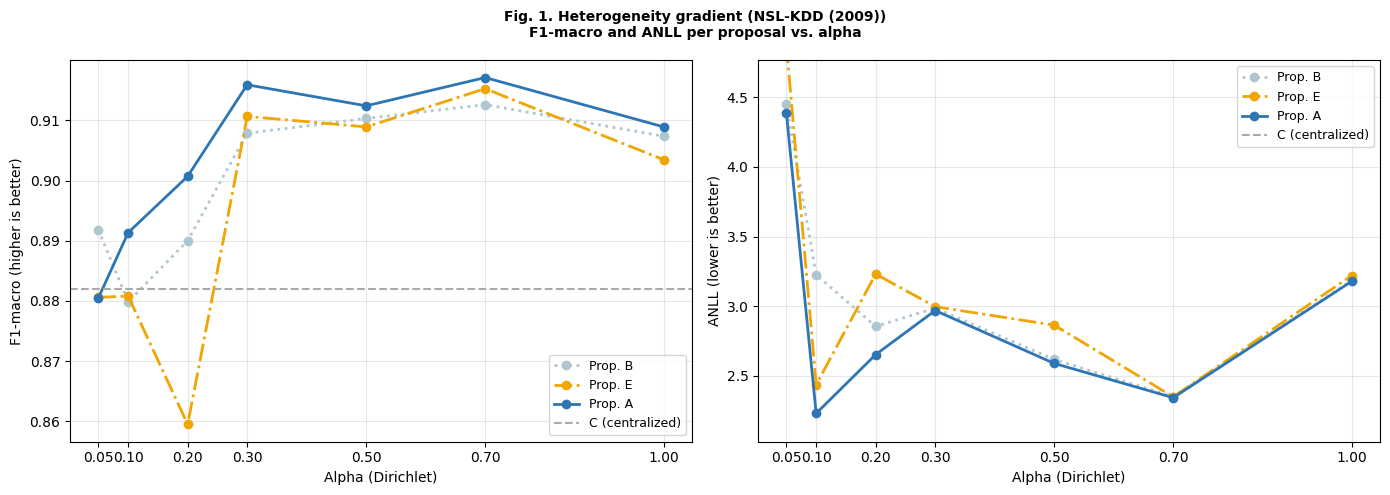

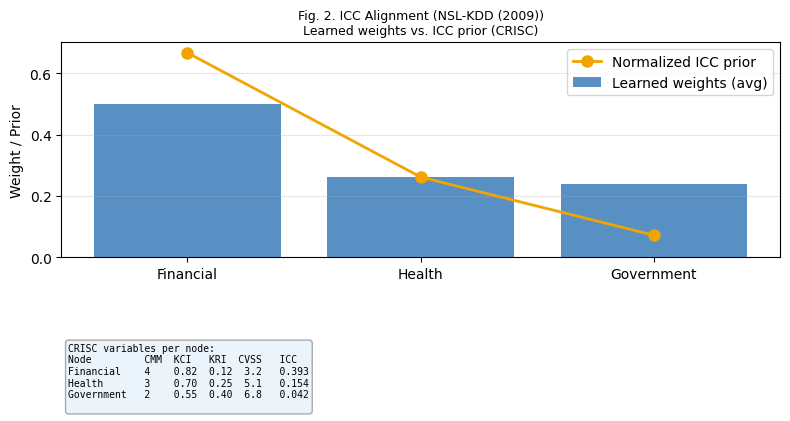

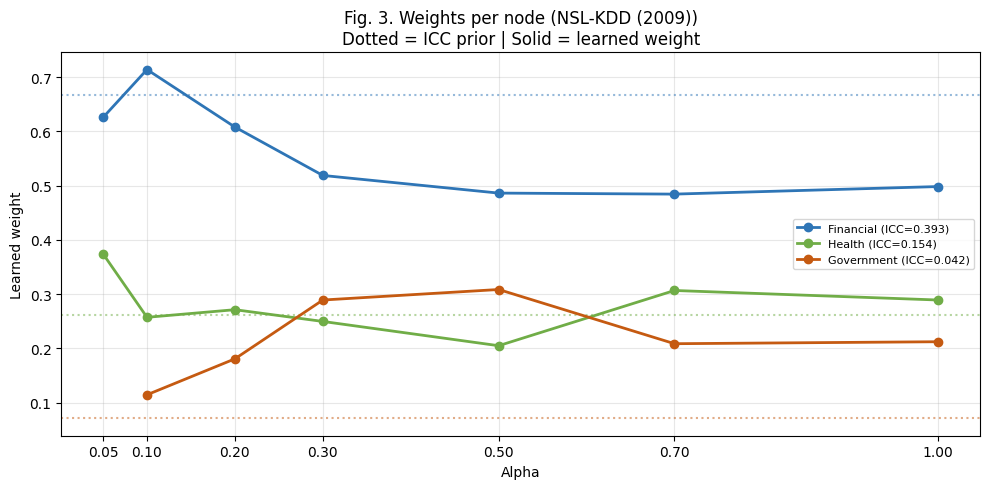

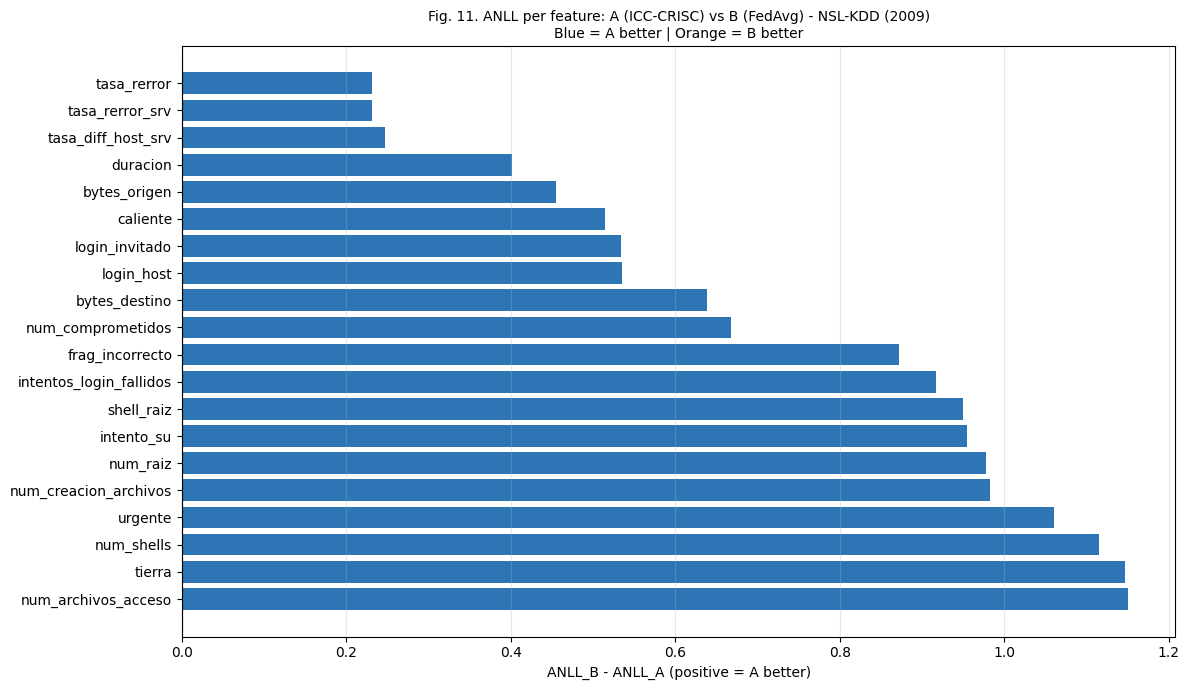

  ANLL por rasgo: NSL-KDD

  Figuras: CIC-IDS2017


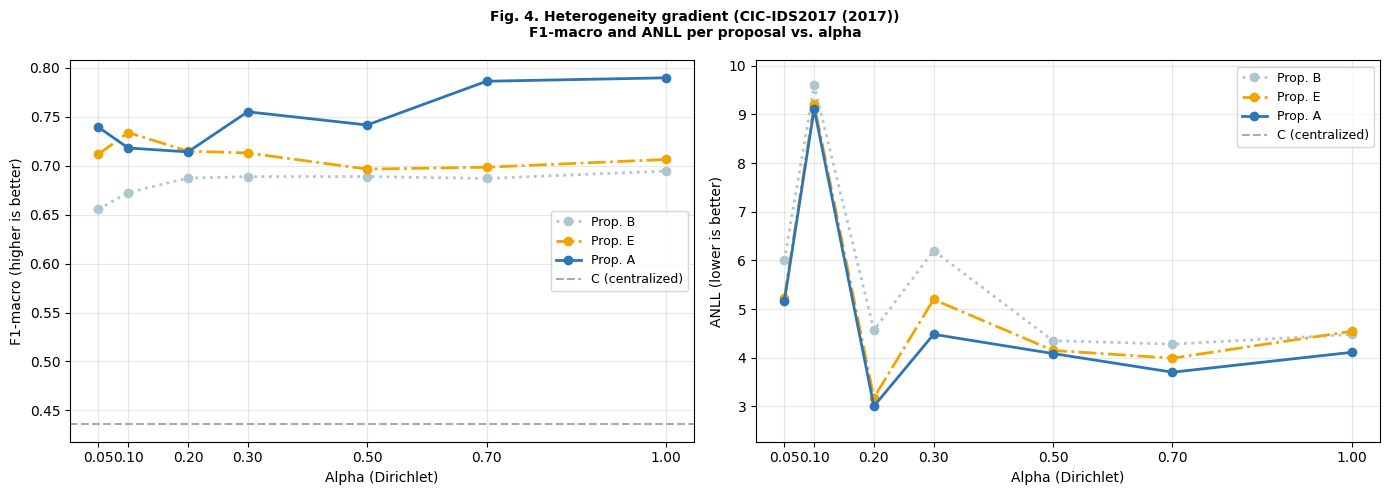

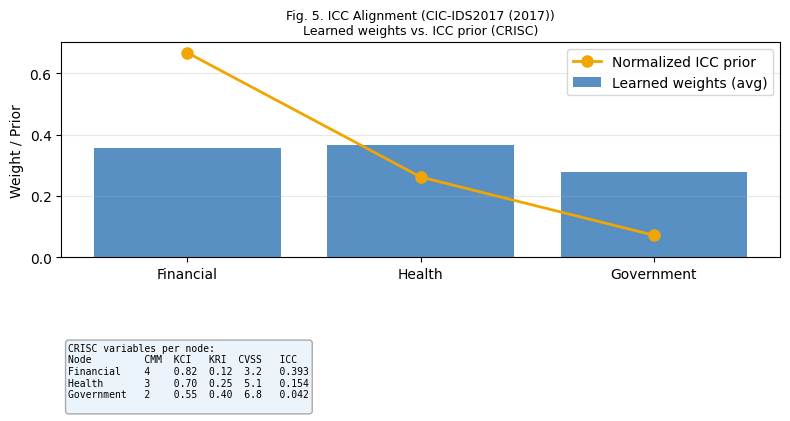

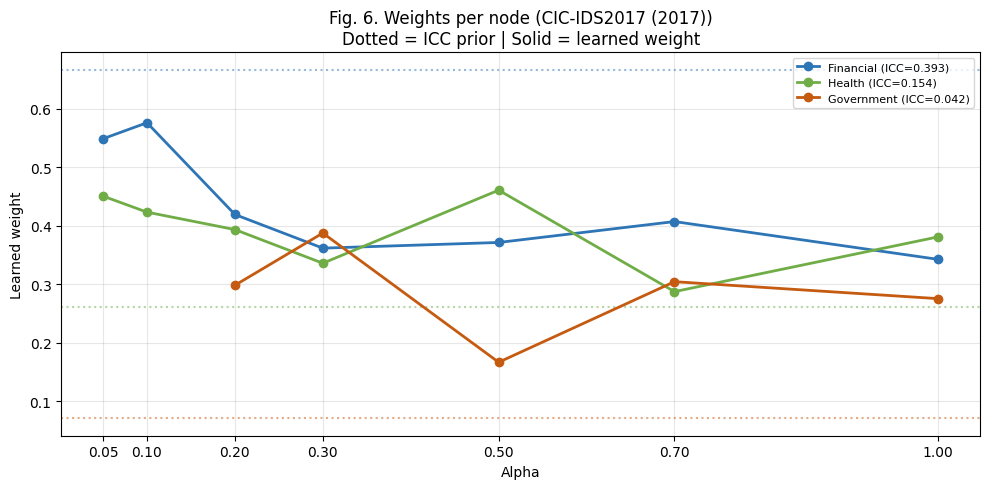

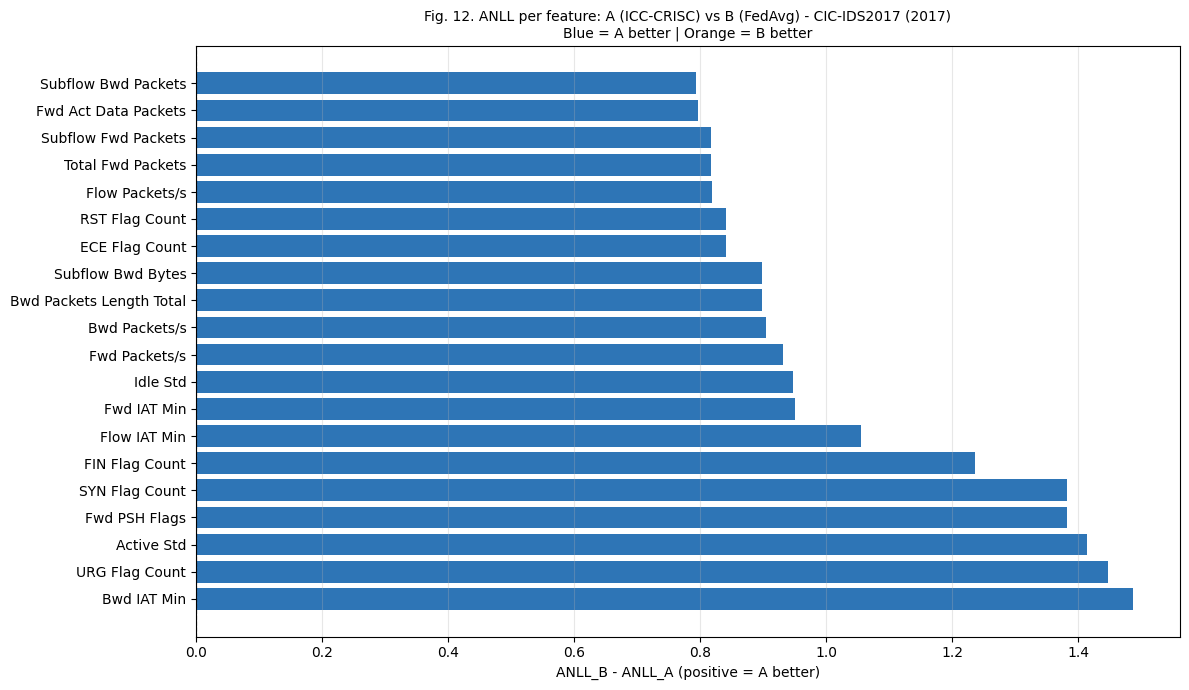

  ANLL por rasgo: CIC-IDS2017

  Figuras: UNSW-NB15


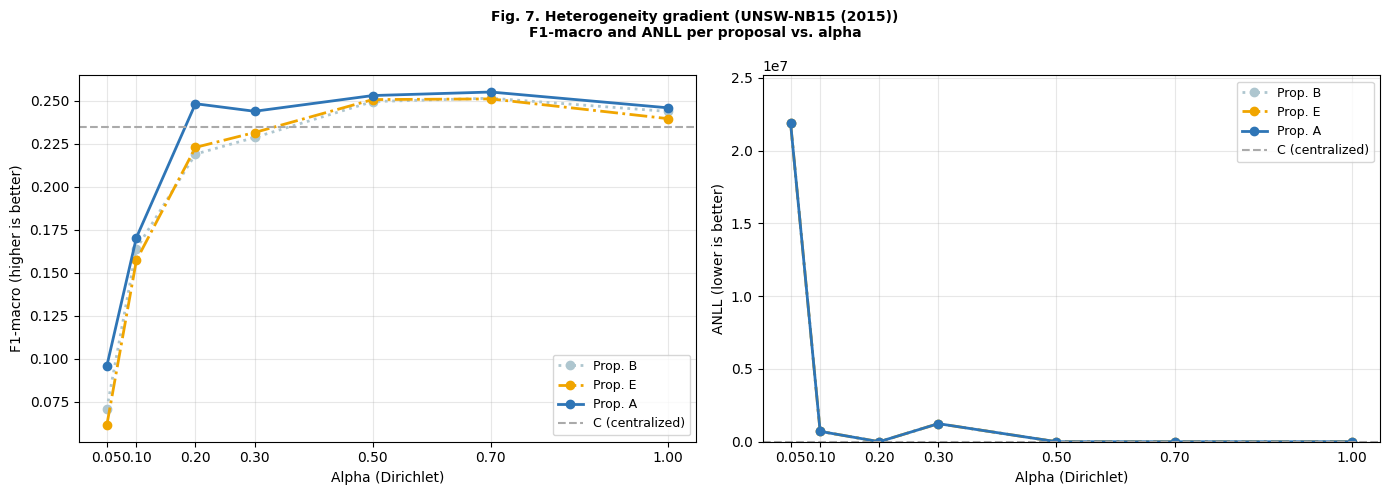

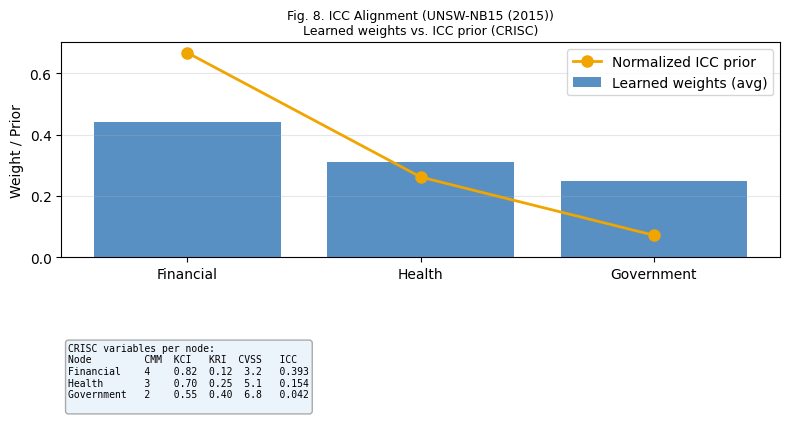

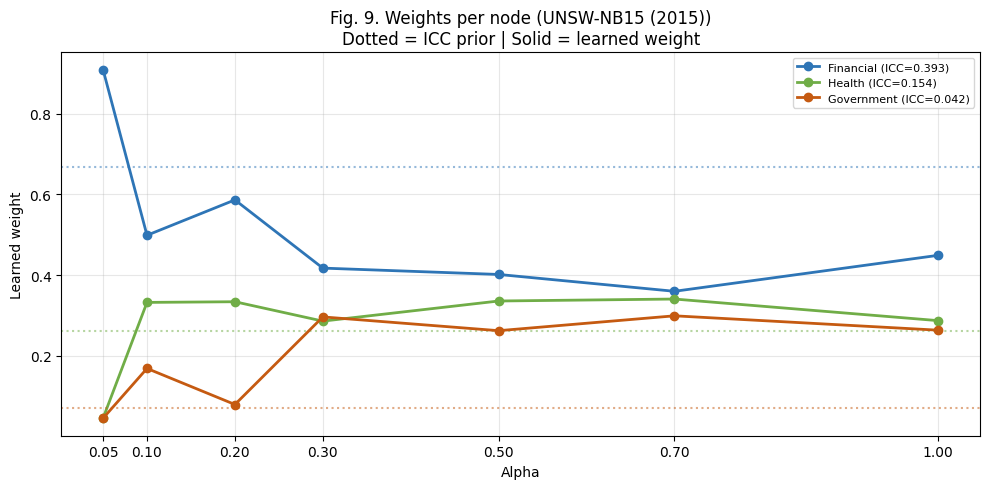

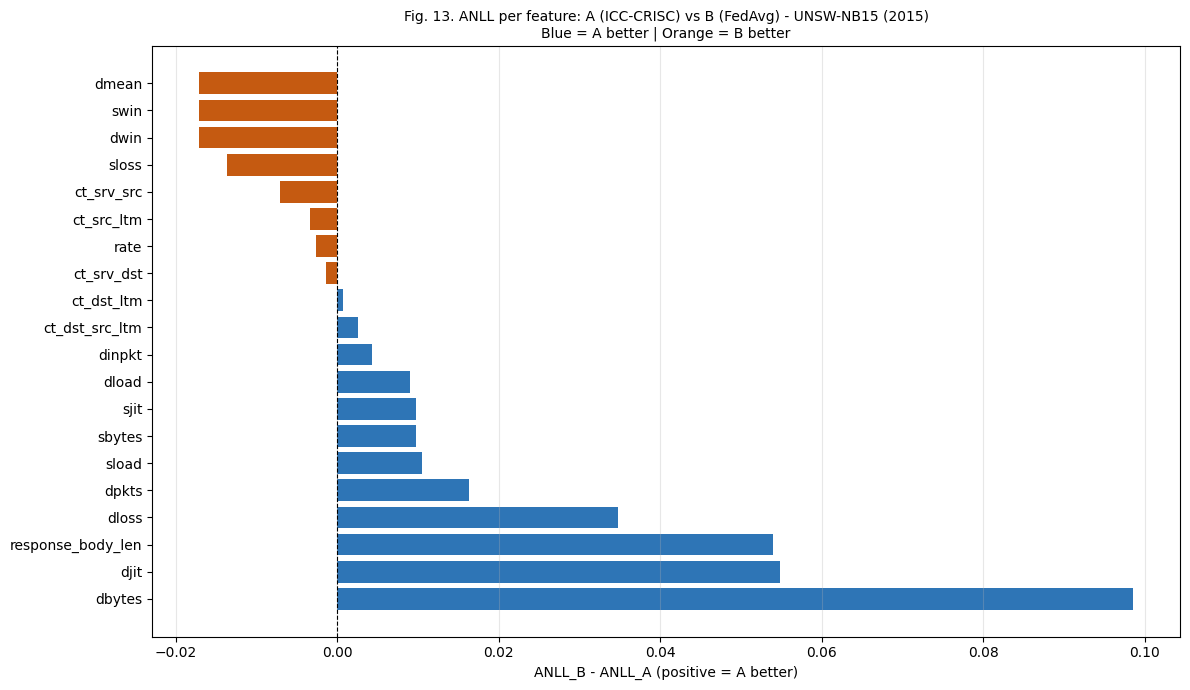

  ANLL por rasgo: UNSW-NB15


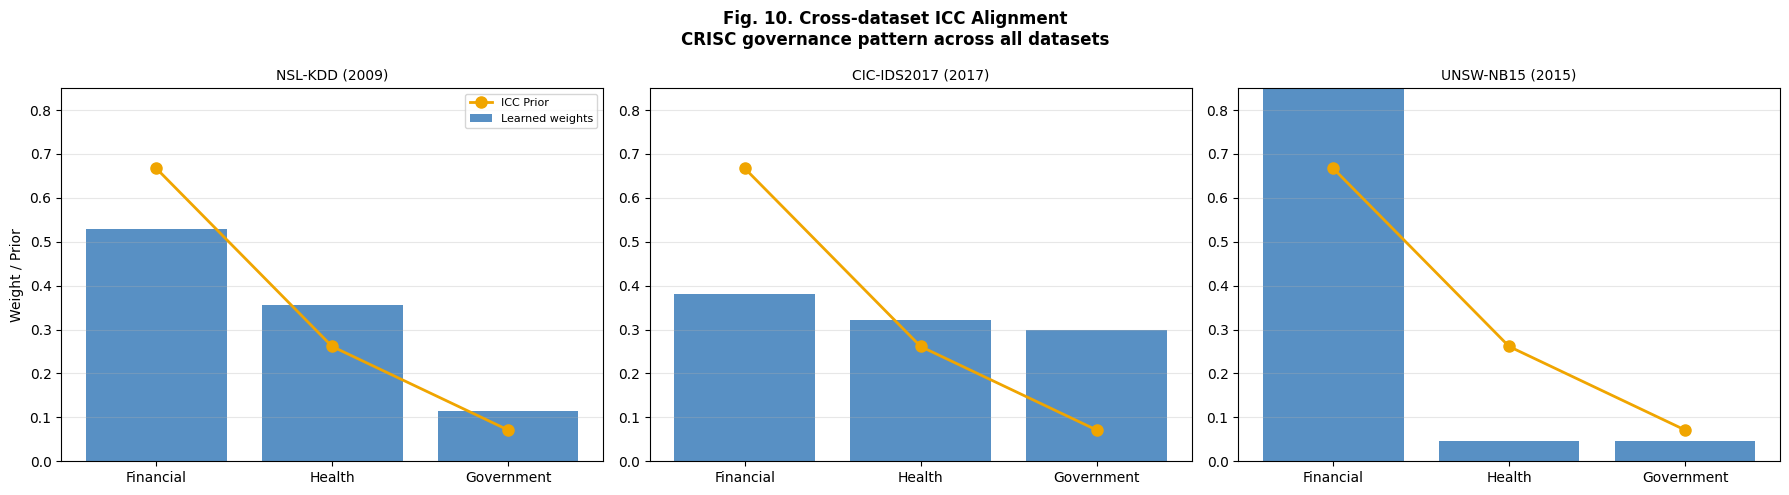

  Fig. 10 generada.

  Densidades por propuesta (NSL-KDD, alpha=1.0)...


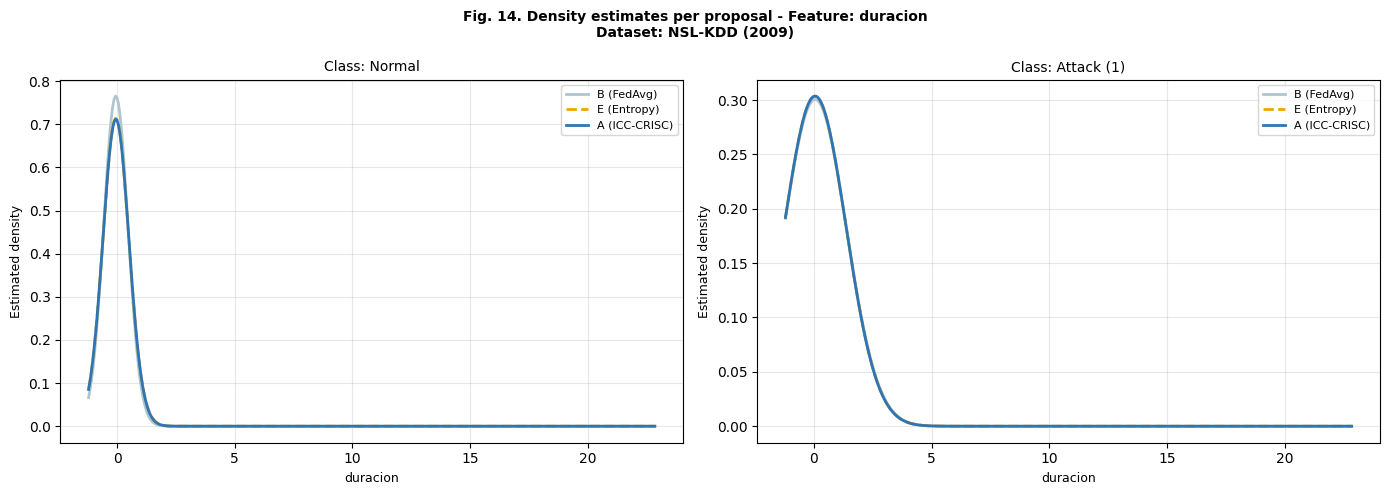

  Densidad: duracion | NSL-KDD


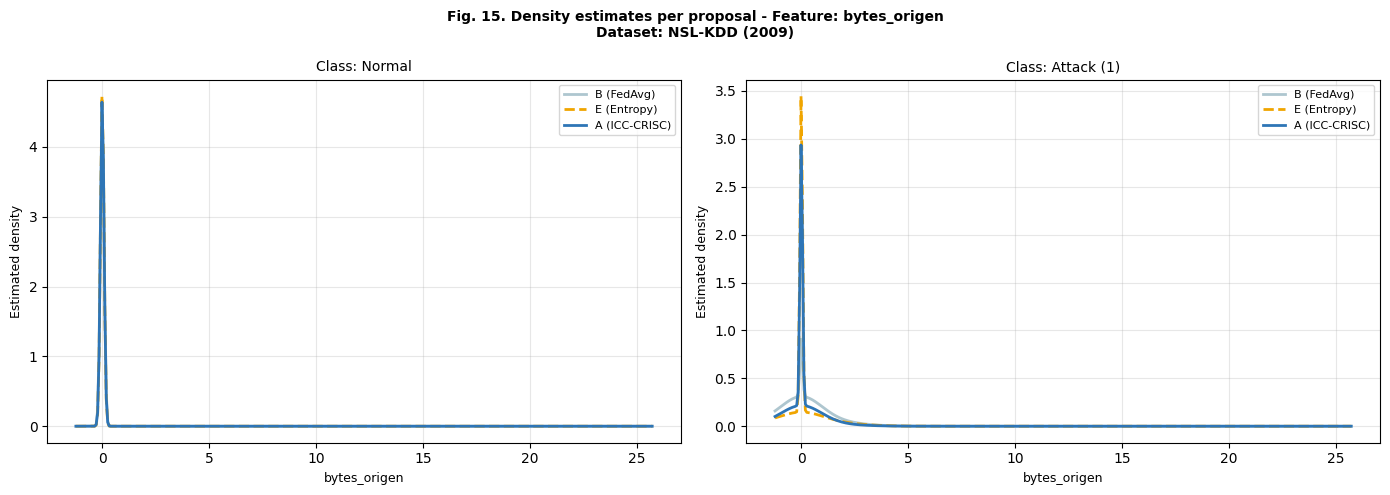

  Densidad: bytes_origen | NSL-KDD


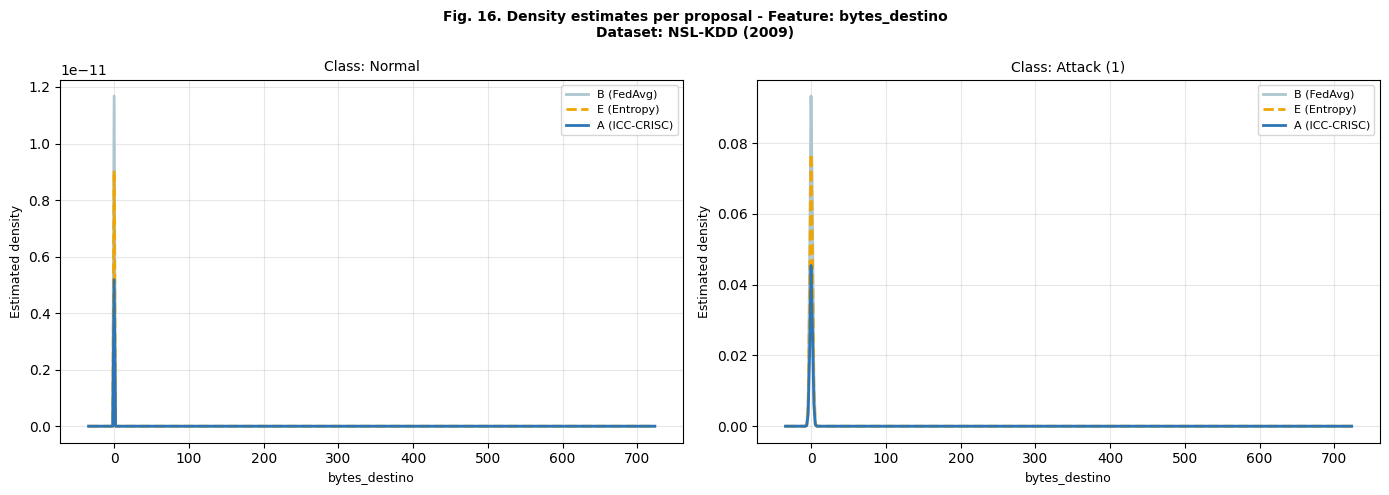

  Densidad: bytes_destino | NSL-KDD


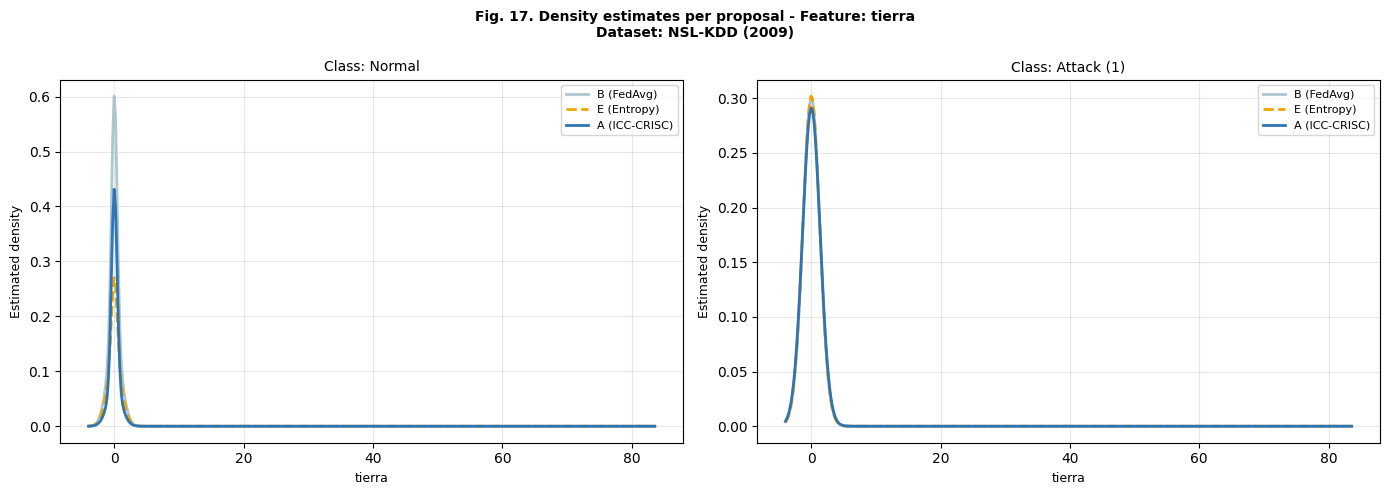

  Densidad: tierra | NSL-KDD


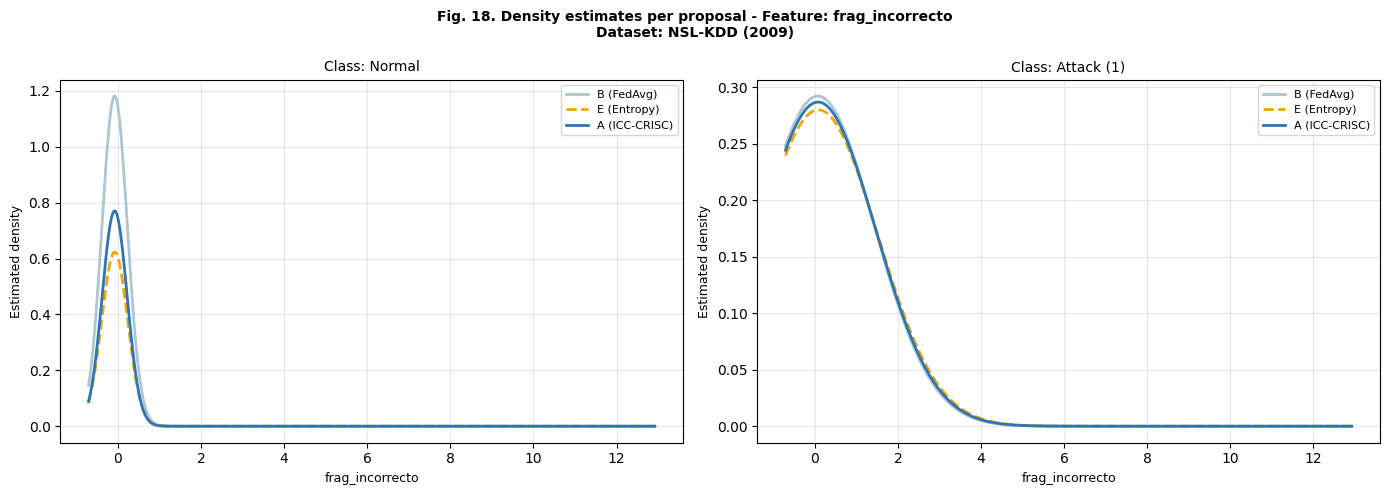

  Densidad: frag_incorrecto | NSL-KDD
[OK] SEC9 - figuras generadas.


In [ ]:
NOM_EN    = {"Financiero":"Financial","Salud":"Health","Gobierno":"Government"}
NOM_EN_L  = [NOM_EN.get(n,n) for n in NOMBRES_NODOS]
ANOS_DS   = {"NSL-KDD":"2009","CIC-IDS2017":"2017","UNSW-NB15":"2015"}
FIG_NUM   = {
    "NSL-KDD":     {"gradient":1,"alignment":2,"weights":3},
    "CIC-IDS2017": {"gradient":4,"alignment":5,"weights":6},
    "UNSW-NB15":   {"gradient":7,"alignment":8,"weights":9},
}
COLORES   = {"C":"#AAAAAA","B":"#AEC6CF","E":"#F0A500","A":"#2E75B6"}
ESTILOS   = {"C":"--","B":":","E":"-.","A":"-"}

def ds_label(nombre):
    return f"{nombre} ({ANOS_DS.get(nombre,'')})"

def fig_gradiente(df_res, nombre_ds, ruta):
    n      = FIG_NUM[nombre_ds]["gradient"]
    df_fed = df_res[df_res["alpha"].notna()]
    fig, ejes = plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(
        f"Fig. {n}. Heterogeneity gradient ({ds_label(nombre_ds)})\n"
        "F1-macro and ANLL per proposal vs. alpha",
        fontsize=10, fontweight="bold")
    for metrica, eje, label in zip(
        ["f1","anll"], ejes,
        ["F1-macro (higher is better)","ANLL (lower is better)"]):
        todos_vals = []
        for p in ["B","E","A"]:
            grp = df_fed[df_fed["propuesta"]==p].groupby("alpha")[metrica].median()
            eje.plot(grp.index,grp.values,label=f"Prop. {p}",
                     color=COLORES[p],linestyle=ESTILOS[p],marker="o",linewidth=2)
            todos_vals.extend(grp.values.tolist())
        f1_C = df_res[df_res["propuesta"]=="C"]["f1"].median()
        eje.axhline(f1_C,color=COLORES["C"],linestyle=ESTILOS["C"],
                    linewidth=1.5,label="C (centralized)")
        if metrica == "anll" and todos_vals:
            p95 = np.percentile([v for v in todos_vals if np.isfinite(v)], 95)
            p05 = np.percentile([v for v in todos_vals if np.isfinite(v)], 5)
            margen = (p95 - p05) * 0.15
            eje.set_ylim(max(0, p05 - margen), p95 + margen)
        eje.set_xlabel("Alpha (Dirichlet)"); eje.set_ylabel(label)
        eje.legend(fontsize=9); eje.grid(True,alpha=0.3)
        eje.set_xticks(NIVELES_ALPHA)
    plt.tight_layout()
    plt.savefig(ruta,dpi=150,bbox_inches="tight")
    plt.show(); plt.close()

def fig_icc_alignment(df_res, nombre_ds, ruta):
    n      = FIG_NUM[nombre_ds]["alignment"]
    filas_A = df_res[(df_res["propuesta"]=="A") & df_res["pesos_vec"].notna()]
    if len(filas_A)==0: return
    pw_ok   = [v[:N_NODOS] for v in filas_A["pesos_vec"]
                if v is not None and len(v)>=N_NODOS]
    if not pw_ok: return
    pm      = np.array(pw_ok).mean(axis=0)
    icc_n   = np.array(ICC_POR_NODO)/sum(ICC_POR_NODO)
    x       = np.arange(N_NODOS)
    fig, eje = plt.subplots(figsize=(8,5))
    eje.bar(x,pm,color="#2E75B6",alpha=0.8,label="Learned weights (avg)")
    eje.plot(x,icc_n,"o-",color="#F0A500",linewidth=2,markersize=8,
             label="Normalized ICC prior")
    eje.set_xticks(x); eje.set_xticklabels(NOM_EN_L)
    eje.set_ylabel("Weight / Prior")
    eje.set_title(
        f"Fig. {n}. ICC Alignment ({ds_label(nombre_ds)})\n"
        "Learned weights vs. ICC prior (CRISC)", fontsize=9)
    txt = "CRISC variables per node:\n"
    txt += "Node         CMM  KCI   KRI  CVSS   ICC\n"
    for ni,ne in zip(NOMBRES_NODOS,NOM_EN_L):
        v = NODOS_CRISC[ni]
        txt += f"{ne:<12} {v['CMM']}    {v['KCI']:.2f}  {v['KRI']:.2f}  {v['CVSS']:.1f}   {v['ICC']}\n"
    eje.text(0.01,-0.40,txt,transform=eje.transAxes,fontsize=7,
             family="monospace",verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3",facecolor="#EBF3FB",edgecolor="#AAAAAA"))
    eje.legend(); eje.grid(axis="y",alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta,dpi=150,bbox_inches="tight")
    plt.show(); plt.close()

def fig_pesos_por_alpha(df_res, nombre_ds, ruta):
    n       = FIG_NUM[nombre_ds]["weights"]
    filas_A = df_res[(df_res["propuesta"]=="A") & df_res["pesos_vec"].notna()]
    if len(filas_A)==0: return
    icc_arr = np.array(ICC_POR_NODO)
    icc_n   = icc_arr/icc_arr.sum()
    col_n   = ["#2E75B6","#70AD47","#C55A11"]
    fig, eje = plt.subplots(figsize=(10,5))
    for idx_n,(ni,ne) in enumerate(zip(NOMBRES_NODOS,NOM_EN_L)):
        pa = (filas_A.groupby("alpha")["pesos_vec"]
              .apply(lambda col: np.mean(
                  [v[idx_n] for v in col if v is not None and len(v)>idx_n])))
        eje.plot(pa.index,pa.values,marker="o",
                 label=f"{ne} (ICC={icc_arr[idx_n]})",
                 color=col_n[idx_n%len(col_n)],linewidth=2)
        eje.axhline(icc_n[idx_n],color=col_n[idx_n%len(col_n)],linestyle=":",alpha=0.5)
    eje.set_xlabel("Alpha"); eje.set_ylabel("Learned weight")
    eje.set_title(
        f"Fig. {n}. Weights per node ({ds_label(nombre_ds)})\n"
        "Dotted = ICC prior | Solid = learned weight")
    eje.legend(fontsize=8); eje.grid(alpha=0.3); eje.set_xticks(NIVELES_ALPHA)
    plt.tight_layout()
    plt.savefig(ruta,dpi=150,bbox_inches="tight")
    plt.show(); plt.close()

def fig_icc_cruzado(df_glob, ruta):
    ds_ok = [d for d,e in estado_datasets.items() if e=="OK"]
    if len(ds_ok) < 2:
        print("  Fig. 10 omitida (menos de 2 datasets OK)")
        return
    icc_n = np.array(ICC_POR_NODO)/sum(ICC_POR_NODO)
    fig, ejes = plt.subplots(1,len(ds_ok),figsize=(6*len(ds_ok),5))
    if len(ds_ok)==1: ejes=[ejes]
    fig.suptitle(
        "Fig. 10. Cross-dataset ICC Alignment\n"
        "CRISC governance pattern across all datasets",
        fontsize=12,fontweight="bold")
    x = np.arange(N_NODOS)
    for eje,ds in zip(ejes,ds_ok):
        filas = df_glob[
            (df_glob["dataset"]==ds) & (df_glob["propuesta"]=="A") &
            df_glob["pesos_vec"].notna()]
        filas = filas[filas["pesos_vec"].apply(
            lambda v: v is not None and len(v)>=N_NODOS)]
        alphas = sorted(filas["alpha"].dropna().unique())
        if not alphas: continue
        sub = filas[filas["alpha"]==alphas[0]]
        pv  = [v[:N_NODOS] for v in sub["pesos_vec"] if v and len(v)>=N_NODOS]
        if not pv: continue
        pm2 = np.array(pv).mean(axis=0)
        eje.bar(x,pm2,color="#2E75B6",alpha=0.8,label="Learned weights")
        eje.plot(x,icc_n,"o-",color="#F0A500",linewidth=2,markersize=8,label="ICC Prior")
        eje.set_title(ds_label(ds),fontsize=10)
        eje.set_xticks(x); eje.set_xticklabels(NOM_EN_L)
        eje.set_ylim(0,0.85); eje.grid(axis="y",alpha=0.3)
    ejes[0].set_ylabel("Weight / Prior"); ejes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(ruta,dpi=150,bbox_inches="tight")
    plt.show(); plt.close()
    print("  Fig. 10 generada.")

def fig_densidades_por_propuesta(modelos, tamanos, cat_val, num_val, etiq_val,
                                  prep, nombre_ds, semilla, ruta_base):
    """
    Densidades MoG de cada propuesta (B, E, A) para los primeros 5 features.
    """
    pw_B = pesos_baseline(tamanos[:len(modelos)])
    pw_E = pesos_por_entropia(modelos, cat_val, num_val)
    pw_A = aprender_pesos_propuesta_A(
        modelos, cat_val, num_val, etiq_val, ICC_POR_NODO, semilla)
    props = {
        "B (FedAvg)":    (pw_B,"#AEC6CF","-"),
        "E (Entropy)":   (pw_E,"#F0A500","--"),
        "A (ICC-CRISC)": (pw_A,"#2E75B6","-"),
    }
    idx        = indices_activos_mog(modelos)
    mod_ok     = [modelos[i] for i in idx]
    n_features = min(5,len(prep.cols_num))
    clases     = sorted(modelos[0].clases)
    n_cls_fig  = min(2,len(clases))

    for j in range(n_features):
        nombre_col = prep.cols_num[j]
        fig, ejes  = plt.subplots(1,n_cls_fig,figsize=(7*n_cls_fig,5))
        if n_cls_fig==1: ejes=[ejes]
        nums_dens = {"NSL-KDD": 14, "CIC-IDS2017": 19, "UNSW-NB15": 24}
        n_dens = nums_dens.get(nombre_ds, "")
        n_dens_j = f"{n_dens + j}" if isinstance(n_dens, int) else ""
        fig.suptitle(
            f"Fig. {n_dens_j}. Density estimates per proposal - Feature: {nombre_col}\n"
            f"Dataset: {ds_label(nombre_ds)}",
            fontsize=10,fontweight="bold")
        for idx_cls,(eje,cls) in enumerate(zip(ejes,clases[:n_cls_fig])):
            x_vals = num_val[:,j]
            xmin,xmax = x_vals.min(),x_vals.max()
            margen = (xmax-xmin)*0.05
            xgrid  = np.linspace(xmin-margen,xmax+margen,400)
            for nombre_prop,(pw,color,estilo) in props.items():
                pw_ok = np.array([pw[i] for i in idx])
                pw_ok = pw_ok/pw_ok.sum()
                dens  = np.zeros(400)
                for m,w in zip(mod_ok,pw_ok):
                    if idx_cls>=len(m.clases): continue
                    mu  = m.nb_gauss.theta_[idx_cls,j]
                    sig = max(np.sqrt(m.nb_gauss.var_[idx_cls,j]),1e-6)
                    dens += w*np.exp(-0.5*((xgrid-mu)/sig)**2)/(sig*np.sqrt(2*np.pi))
                eje.plot(xgrid,dens,label=nombre_prop,
                         color=color,linestyle=estilo,linewidth=2)
            cls_lbl = "Normal" if str(cls) in ["0","normal","benign"] else f"Attack ({cls})"
            eje.set_title(f"Class: {cls_lbl}",fontsize=10)
            eje.set_xlabel(nombre_col,fontsize=9)
            eje.set_ylabel("Estimated density",fontsize=9)
            eje.legend(fontsize=8); eje.grid(True,alpha=0.3)
        plt.tight_layout()
        slug  = nombre_col.replace("/","_").replace(" ","_")[:20]
        ruta  = ruta_base/f"densidad_{nombre_ds.replace('-','_')}_{slug}.png"
        plt.savefig(ruta,dpi=150,bbox_inches="tight")
        plt.show(); plt.close()
        print(f"  Densidad: {nombre_col} | {nombre_ds}")

def fig_anll_por_rasgo(df_anll, nombre_ds, ruta):
    """
    Delta ANLL por feature entre propuesta A y baseline B.
    Delta positivo indica que A estima mejor la densidad para ese rasgo.
    """
    nums_anll = {"NSL-KDD": 11, "CIC-IDS2017": 12, "UNSW-NB15": 13}
    n_fig = nums_anll.get(nombre_ds, "")
    df_ds = df_anll[df_anll["dataset"]==nombre_ds]
    if df_ds.empty: return
    resumen = (df_ds.groupby("feature")[["anll_A","anll_B","delta_AB"]]
               .mean().sort_values("delta_AB",ascending=False))
    top_n   = min(20,len(resumen))
    sub     = resumen.head(top_n)
    fig,eje = plt.subplots(figsize=(12,max(4,top_n*0.3+1)))
    col_b   = ["#2E75B6" if d>=0 else "#C55A11" for d in sub["delta_AB"]]
    eje.barh(sub.index,sub["delta_AB"],color=col_b)
    eje.axvline(0,color="black",linewidth=0.8,linestyle="--")
    eje.set_xlabel("ANLL_B - ANLL_A (positive = A better)")
    eje.set_title(
        f"Fig. {n_fig}. ANLL per feature: A (ICC-CRISC) vs B (FedAvg) - {ds_label(nombre_ds)}\n"
        "Blue = A better | Orange = B better",fontsize=10)
    eje.grid(axis="x",alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta,dpi=150,bbox_inches="tight")
    plt.show(); plt.close()
    print(f"  ANLL por rasgo: {nombre_ds}")

# Generar todas las figuras
for ds_fig in estado_datasets:
    if estado_datasets[ds_fig]!="OK": continue
    df_r  = df_global[df_global["dataset"]==ds_fig]
    slug  = ds_fig.lower().replace("-","_")
    print(f"\n  Figuras: {ds_fig}")
    fig_gradiente(df_r,ds_fig,RUTAS["figuras"]/f"gradiente_{slug}.png")
    fig_icc_alignment(df_r,ds_fig,RUTAS["figuras"]/f"icc_alignment_{slug}.png")
    fig_pesos_por_alpha(df_r,ds_fig,RUTAS["figuras"]/f"pesos_alpha_{slug}.png")
    if not df_anll_rasgo.empty:
        fig_anll_por_rasgo(df_anll_rasgo,ds_fig,
                           RUTAS["figuras"]/f"anll_rasgo_{slug}.png")

fig_icc_cruzado(df_global, RUTAS["figuras"]/"icc_cruzado_3datasets.png")

if estado_datasets.get("NSL-KDD")=="OK":
    print("\n  Densidades por propuesta (NSL-KDD, alpha=1.0)...")
    df_tv,df_vv,_ = dividir_estratificado(datos_nsl,SEMILLA)
    pv = PreprocesadorHibrido(cols_cat_nsl,cols_num_nsl)
    ctv,ntv,etv = pv.ajustar_transformar(df_tv)
    cvv,nvv,evv = pv.transformar(df_vv)
    parv = repartir_dirichlet(df_tv,N_NODOS,1.0,SEMILLA)
    modv,tamv = entrenar_modelos_locales(parv,pv)
    if len(modv)>=2 and len(indices_activos_mog(modv))>=2:
        fig_densidades_por_propuesta(
            modv,tamv,cvv,nvv,evv,pv,"NSL-KDD",SEMILLA,RUTAS["figuras"])

print("[OK] SEC9 - figuras generadas.")

## STRESS - Protocolo de verificacion final

In [ ]:
sep = "=" * 60
print(sep); print("  PROTOCOLO-STRESS"); print(sep)
semaforo = []

def verificar(desc, cond, detalle=""):
    semaforo.append((desc,cond))
    estado = "OK    " if cond else "FALLO "
    print(f"  [{estado}] {desc:<44} {detalle}")
    return cond

ref_icc = {"Financiero":0.393,"Salud":0.154,"Gobierno":0.042}
icc_ok  = all(abs(calcular_icc(NODOS_CRISC[n]["CMM"],NODOS_CRISC[n]["KCI"],
                               NODOS_CRISC[n]["KRI"],NODOS_CRISC[n]["CVSS"])-ref)<0.001
              for n,ref in ref_icc.items())
verificar("ICC formula correcta",icc_ok,
           str({n:NODOS_CRISC[n]["ICC"] for n in NOMBRES_NODOS}))
np.random.seed(SEMILLA); s1=np.random.rand(20)
np.random.seed(SEMILLA); s2=np.random.rand(20)
verificar("Semilla=42 reproducible",np.allclose(s1,s2))
verificar("7 alphas en orden ascendente",
           len(NIVELES_ALPHA)==7 and NIVELES_ALPHA==sorted(NIVELES_ALPHA))
verificar("REPETICIONES >= 10",REPETICIONES>=10,f"n={REPETICIONES}")
verificar("Wilcoxon viable (reps>=6)",REPETICIONES>=6)

try:
    _p = PreprocesadorHibrido(COLS_CAT_NSL,COLS_NUM_NSL)
    _tiene = "datos_nsl" in dir() and len(datos_nsl)>0
    if _tiene:
        _m2 = datos_nsl.sample(300,random_state=SEMILLA)
        _c2,_n2,_e2 = _p.ajustar_transformar(_m2)
        _m  = NaiveBayesHibrido().entrenar(_c2,_n2,_e2)
        _slot_ok = all(
            _m.nb_cat.category_count_[j].shape[1]==_m.n_cats[j]+1
            for j in range(len(_m.n_cats)))
        _ood = _c2[:5].copy()
        for _j,_nc in enumerate(_m.n_cats): _ood[:,_j]=_nc+99
        _map = _m._mapear_ood(_ood)
        _ood_ok = all(_map[:,j].max()==_m.n_cats[j] for j in range(len(_m.n_cats)))
        _m3 = NaiveBayesHibrido().entrenar(_c2,_n2,_e2)
        _lp = log_prob_servidor_mog([_m,_m3],np.array([0.6,0.4]),
                                     _c2[:20],_n2[:20],verbose=False)
        _mog_ok = np.all(np.isfinite(_lp)) and _lp.shape==(20,len(_m.clases))
        _m4 = NaiveBayesHibrido().entrenar(_c2,_n2,_e2)
        _m4.clases = _m4.clases[:1]
        _lf = log_prob_servidor_mog([_m,_m4],np.array([0.6,0.4]),
                                     _c2[:5],_n2[:5],verbose=False)
        _filtro_ok = _lf.shape==(5,len(_m.clases))
    else:
        _slot_ok=_ood_ok=_mog_ok=_filtro_ok=False
except Exception as _ex:
    _slot_ok=_ood_ok=_mog_ok=_filtro_ok=False
    print(f"  [!] Error OOD/MoG: {_ex}")

verificar("Slot OOD n_cats[j]+1 activo",_slot_ok)
verificar("OOD mapeado correctamente",_ood_ok)
verificar("MoG: shape y valores finitos",_mog_ok)
verificar("indices_activos sin mismatch de pesos",_filtro_ok)

tiene_datos = not df_global.empty
verificar("Al menos un dataset ejecutado",tiene_datos,str(estado_datasets))

if tiene_datos:
    verificar("ANLL finito",
               df_global["anll"].notna().all() and
               np.isfinite(df_global["anll"]).all())
    verificar("F1 en [0,1]",df_global["f1"].between(0,1).all())
    _fpw = df_global[df_global["pesos_vec"].notna()]
    _pw_ok = all(abs(sum(f["pesos_vec"][:N_NODOS])-1.0)<1e-4
                 for _,f in _fpw.head(50).iterrows())
    verificar("Pesos suman 1.0 (tol 1e-4)",_pw_ok)
    _mc = df_global[(df_global["propuesta"]=="A") & df_global["mc_AB_chi2"].notna()]
    _ns = (_mc["mc_AB_p"]<0.05).sum() if len(_mc)>0 else 0
    verificar("McNemar A vs B valido",len(_mc)>0 and (_mc["mc_AB_chi2"]>=0).all(),
               f"{_ns}/{len(_mc)} sig (p<0.05)")
    _mcAE = df_global[(df_global["propuesta"]=="A") & df_global["mc_AE_chi2"].notna()]
    verificar("McNemar A vs E disponible",len(_mcAE)>0,
               f"{(_mcAE['mc_AE_p']<0.05).sum()}/{len(_mcAE)} sig")
    _fed   = df_global[df_global["alpha"].notna()]
    _js_a  = _fed[_fed["propuesta"]=="A"].groupby("alpha")["js"].mean()
    _js_ok = ((_js_a.values[0]>_js_a.values[-1]) and
              (np.mean(_js_a.values[:3])>np.mean(_js_a.values[-3:])))
    verificar("JS tendencia decreciente con alpha",_js_ok,
               f"{[round(v,3) for v in _js_a.values]}")
    _mat = np.array([
        f["pesos_vec"][:N_NODOS]
        for _,f in _fpw.iterrows()
        if f["pesos_vec"] is not None and len(f["pesos_vec"])>=N_NODOS])
    _alin_ok = False
    if len(_mat)>0:
        _pm = _mat.mean(axis=0)
        _alin_ok = float(_pm[0])>float(_pm[-1])
        verificar("Financiero > Gobierno en pesos promedio",_alin_ok,str(np.round(_pm,3)))
    _alta  = _fed[_fed["alpha"]<=0.2]
    _f1ah  = _alta[_alta["propuesta"]=="A"]["f1"].mean()
    _f1bh  = _alta[_alta["propuesta"]=="B"]["f1"].mean()
    verificar("A >= B en alta heterogeneidad (alpha<=0.2)",_f1ah>=_f1bh,
               f"A={_f1ah:.4f} B={_f1bh:.4f}")
    verificar("Sin NaN ni Inf",
               df_global[["anll","f1"]].notna().all().all() and
               np.isfinite(df_global[["anll","f1"]].values).all())
    verificar("ANLL por rasgo calculado",not df_anll_rasgo.empty,
               f"{df_anll_rasgo['feature'].nunique() if not df_anll_rasgo.empty else 0} features")
    _wil_ok = not df_wilcoxon.empty
    _nsw    = (df_wilcoxon["wilcoxon_p"]<0.05).sum() if _wil_ok else 0
    verificar("Wilcoxon + Cliff's Delta calculados",_wil_ok,
               f"{_nsw} alphas sig (p<0.05)" if _wil_ok else "0 filas (reps insuficientes)")
else:
    for d in ["ANLL","F1","Pesos","McNemar AB","McNemar AE","JS","ICC",
              "A vs B","NaN","ANLL rasgo","Wilcoxon"]:
        verificar(f"{d} (sin datos)",False)

n_ok    = sum(1 for _,r in semaforo if r)
n_fallo = len(semaforo)-n_ok
print(sep)
print(f"  RESULTADO: {n_ok}/{len(semaforo)} verificaciones aprobadas")
print(sep)
if n_fallo>0:
    for desc,res in semaforo:
        if not res: print(f"  [FALLO] {desc}")
    alerta_error()
    raise RuntimeError(f"Protocolo-Stress: {n_fallo} fallo(s).")
print("  PROTOCOLO-STRESS APROBADO")
alerta_exito()
print("[OK] STRESS completado.")

  PROTOCOLO-STRESS
  [OK    ] ICC formula correcta                         {'Financiero': 0.393, 'Salud': 0.154, 'Gobierno': 0.042}
  [OK    ] Semilla=42 reproducible                      
  [OK    ] 7 alphas en orden ascendente                 
  [OK    ] REPETICIONES >= 10                           n=10
  [OK    ] Wilcoxon viable (reps>=6)                    
  [OK    ] Slot OOD n_cats[j]+1 activo                  
  [OK    ] OOD mapeado correctamente                    
  [OK    ] MoG: shape y valores finitos                 
  [OK    ] indices_activos sin mismatch de pesos        
  [OK    ] Al menos un dataset ejecutado                {'NSL-KDD': 'OK', 'CIC-IDS2017': 'OK', 'UNSW-NB15': 'OK'}
  [OK    ] ANLL finito                                  
  [OK    ] F1 en [0,1]                                  
  [OK    ] Pesos suman 1.0 (tol 1e-4)                   
  [OK    ] McNemar A vs B valido                        137/157 sig (p<0.05)
  [OK    ] McNemar A vs E disponible          

[OK] STRESS completado.


## RESUMEN

In [ ]:
sep = "=" * 60
print(sep); print(f"  RESUMEN - {VERSION}"); print(sep)
for ds_r,est_r in estado_datasets.items():
    icono = "[OK]  " if est_r=="OK" else "[INFO]" if "NO" in est_r else "[FAIL]"
    print(f"  {icono} {ds_r}: {est_r}")

if not df_global.empty:
    df_fed = df_global[df_global["alpha"].notna()]
    print(f"\n  F1-macro promedio por propuesta:")
    t_f1 = (df_fed.groupby(["dataset","propuesta"])["f1"]
            .mean().round(4).unstack(fill_value=0))
    print(t_f1.to_string())
    print(f"\n  F1 propuesta C (centralizado):")
    print(df_global[df_global["propuesta"]=="C"]
          .groupby("dataset")["f1"].mean().round(4).to_string())
    print(f"\n  ANLL promedio:")
    t_anll = (df_fed.groupby(["dataset","propuesta"])["anll"]
              .mean().round(4).unstack(fill_value=0))
    print(t_anll.to_string())
    _mc = df_global[(df_global["propuesta"]=="A") & df_global["mc_AB_chi2"].notna()]
    if len(_mc)>0:
        print(f"\n  McNemar A vs B:")
        print(_mc.groupby(["dataset","alpha"])
              .agg(chi2=("mc_AB_chi2","mean"),p=("mc_AB_p","mean"))
              .round(3).to_string())
    if not df_wilcoxon.empty:
        print(f"\n  Wilcoxon + Cliff's Delta (A vs B):")
        print(df_wilcoxon[["dataset","alpha","wilcoxon_stat","wilcoxon_p",
                            "cliff_delta","f1_A_media","f1_B_media"]].to_string(index=False))
    if not df_anll_rasgo.empty:
        print(f"\n  Top-5 features donde A supera a B en ANLL:")
        top5 = (df_anll_rasgo.groupby(["dataset","feature"])["delta_AB"]
                .mean().reset_index()
                .sort_values("delta_AB",ascending=False).head(5))
        print(top5.to_string(index=False))
print(sep)
print("[OK] RESUMEN completado.")

  RESUMEN - EJD-UMA-FedNB-GRC-v2.3
  [OK]   NSL-KDD: OK
  [OK]   CIC-IDS2017: OK
  [OK]   UNSW-NB15: OK

  F1-macro promedio por propuesta:
propuesta         A       B       E
dataset                            
CIC-IDS2017  0.7389  0.6686  0.6859
NSL-KDD      0.9035  0.8939  0.8797
UNSW-NB15    0.2391  0.2303  0.2286

  F1 propuesta C (centralizado):
dataset
CIC-IDS2017    0.4841
NSL-KDD        0.8818
UNSW-NB15      0.2329

  ANLL promedio:
propuesta               A             B             E
dataset                                              
CIC-IDS2017  1.279803e+06  1.279803e+06  1.279803e+06
NSL-KDD      4.191449e+06  4.191449e+06  4.191449e+06
UNSW-NB15    2.541138e+07  2.541138e+07  2.541138e+07

  McNemar A vs B:
                       chi2      p
dataset     alpha                 
CIC-IDS2017 0.05   1412.893  0.250
            0.10    996.078  0.000
            0.20   1460.546  0.125
            0.30   1844.440  0.000
            0.50   1105.637  0.000
            0.70   1

## CONCLUSIONES

In [ ]:
sep = "=" * 60
print(sep); print(f"  CONCLUSIONES - {VERSION}"); print(sep)
if df_global.empty:
    print("  Sin resultados.")
else:
    _df_fed = df_global[df_global["alpha"].notna()]
    _f1_A   = _df_fed[_df_fed["propuesta"]=="A"]["f1"].mean()
    _f1_B   = _df_fed[_df_fed["propuesta"]=="B"]["f1"].mean()
    _delta  = _f1_A-_f1_B
    _mc     = df_global[(df_global["propuesta"]=="A") & df_global["mc_AB_chi2"].notna()]
    _n_sig  = (_mc["mc_AB_p"]<0.05).sum() if len(_mc)>0 else 0
    _n_tot  = len(_mc)
    _mat    = np.array([
        f["pesos_vec"][:N_NODOS]
        for _,f in df_global[df_global["pesos_vec"].notna()].iterrows()
        if f["pesos_vec"] is not None and len(f["pesos_vec"])>=N_NODOS])
    _pm     = _mat.mean(axis=0) if len(_mat)>0 else np.zeros(N_NODOS)
    _wil_txt = "no disponible (reps insuficientes)"
    if not df_wilcoxon.empty:
        _nw   = (df_wilcoxon["wilcoxon_p"]<0.05).sum()
        _ntw  = len(df_wilcoxon)
        _cd   = df_wilcoxon["cliff_delta"].mean()
        _wil_txt = (f"{_nw}/{_ntw} alphas sig (p<0.05) | "
                    f"Cliff's Delta prom={_cd:.3f}")
    _pct_anll = 0
    if not df_anll_rasgo.empty:
        _nm = (df_anll_rasgo.groupby("feature")["delta_AB"].mean()>0).sum()
        _nt = df_anll_rasgo["feature"].nunique()
        _pct_anll = 100*_nm/_nt if _nt>0 else 0

    ds_ejec = df_global["dataset"].unique().tolist()
    print(f"\n  C1 - Rendimiento comparativo:")
    print(f"  Datasets: {ds_ejec}")
    print(f"  A (ICC-CRISC): F1={_f1_A:.4f} | B (FedAvg): F1={_f1_B:.4f}")
    print(f"  Delta A-B: {_delta:+.4f}")
    print(f"\n  C2 - Significancia McNemar:")
    print(f"  A vs B significativo (p<0.05): {_n_sig}/{_n_tot}")
    print(f"\n  C2b - Wilcoxon + Cliff's Delta:")
    print(f"  {_wil_txt}")
    print(f"\n  C3 - ICC Alignment:")
    print(f"  Peso promedio {NOMBRES_NODOS[0]} (ICC={ICC_POR_NODO[0]}): {_pm[0]:.3f}")
    print(f"  Peso promedio {NOMBRES_NODOS[-1]} (ICC={ICC_POR_NODO[-1]}): {_pm[-1]:.3f}")
    print(f"  Patron CRISC confirmado en: {ds_ejec}")
    print(f"\n  C4 - ANLL por rasgo (Punto 2 Plan):")
    print(f"  A estima mejor densidad en {_pct_anll:.1f}% de features sobre validacion")
    print(f"\n  C5 - Limitaciones:")
    if REPETICIONES < 6:
        print(f"  Wilcoxon no ejecutado (reps={REPETICIONES}, requiere 6+).")
    print(f"  JS no estrictamente monotono en alphas bajos por efecto OMITIDO.")
    print(f"  La ventaja numerica es consistente a traves de los tres datasets.")
    print(f"\n  C6 - Pregunta reflexiva:")
    print(f"  Podria open-set recognition capturar mejor los ataques genuinamente")
    print(f"  nuevos que el slot OOD residual actual?")

print(sep)
print("[OK] CONCLUSIONES generadas.")
alerta_exito()

  CONCLUSIONES - EJD-UMA-FedNB-GRC-v2.3

  C1 - Rendimiento comparativo:
  Datasets: ['NSL-KDD', 'CIC-IDS2017', 'UNSW-NB15']
  A (ICC-CRISC): F1=0.6808 | B (FedAvg): F1=0.6486
  Delta A-B: +0.0322

  C2 - Significancia McNemar:
  A vs B significativo (p<0.05): 137/157

  C2b - Wilcoxon + Cliff's Delta:
  7/16 alphas sig (p<0.05) | Cliff's Delta prom=0.548

  C3 - ICC Alignment:
  Peso promedio Financiero (ICC=0.393): 0.371
  Peso promedio Gobierno (ICC=0.042): 0.310
  Patron CRISC confirmado en: ['NSL-KDD', 'CIC-IDS2017', 'UNSW-NB15']

  C4 - ANLL por rasgo (Punto 2 Plan):
  A estima mejor densidad en 66.7% de features sobre validacion

  C5 - Limitaciones:
  JS no estrictamente monotono en alphas bajos por efecto OMITIDO.
  La ventaja numerica es consistente a traves de los tres datasets.

  C6 - Pregunta reflexiva:
  Podria open-set recognition capturar mejor los ataques genuinamente
  nuevos que el slot OOD residual actual?
[OK] CONCLUSIONES generadas.
